In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from scipy import integrate
from scipy.optimize import curve_fit
from scipy.stats import gaussian_kde
import matplotlib.patches as mpatches

%matplotlib notebook 

In [12]:
nb_acq = 7

# Importation des datas

In [2]:
'''Lignes pairs de Data: temps '''
'''Lignes impairs de Data: Amplitude '''
DataBa1 = np.zeros((2*3000*7,2560)) 
DataNE1 = np.zeros((2*3000*7,2560))
DataBa2 = np.zeros((2*3000*8,2560)) 
DataNE2 = np.zeros((2*3000*8,2560))

In [3]:
fichier1 = open('ToF_Cf_1100_0_6.txt','r')
fichier2 = open('ToF_Cf_7_14.txt','r')

In [ ]:
listeBrute1 = fichier1.readlines()
listeBrute2 = fichier2.readlines()
fichier1.close()
fichier2.close()

In [5]:
'''0:BaF2'''
'''1:Ne213'''
    
'''Création de Data'''
for i in range(6, len(listeBrute1) - 7*2566):
    acq_nb=i//2566
    pt_nb=i%2566-6
    if pt_nb>=0:
        valeurs = listeBrute1[i].strip().split(';')
        #if pt_nb==1538:
            #print(acq_nb, valeurs[0])
        
        DataBa1[2*(acq_nb)][pt_nb]=float(valeurs[0])
        DataBa1[2*(acq_nb)+1][pt_nb]=-float(valeurs[1]) #conversion en tension positive 
        DataNE1[2*(acq_nb)][pt_nb]=float(valeurs[2])
        DataNE1[2*(acq_nb)+1][pt_nb]=-float(valeurs[3]) 

In [6]:
'''0:BaF2'''
'''1:Ne213'''
    
'''Création de Data'''
for i in range(6, len(listeBrute2) - 8*2566):
    acq_nb=i//2566
    pt_nb=i%2566-6
    if pt_nb>=0:
        valeurs = listeBrute2[i].strip().split(';')
        #if pt_nb==1538:
            #print(acq_nb, valeurs[0])
        
        DataBa2[2*(acq_nb)][pt_nb]=float(valeurs[0])
        DataBa2[2*(acq_nb)+1][pt_nb]=-float(valeurs[1]) #conversion en tension positive 
        DataNE2[2*(acq_nb)][pt_nb]=float(valeurs[2])
        DataNE2[2*(acq_nb)+1][pt_nb]=-float(valeurs[3]) 

### Suppression de la valeur moyenne des signaux

In [7]:
'''Définir le zéro + le max + supprimer les détections où NE213 avant'''
def max_lim(liste, i_lim):
    M=0
    for i in range(i_lim):
        if liste[i]>M:
            M=liste[i]
    return M
    
    
for k in range(3000*7):
    moyBa=0
    moyNE=0
    for l in range(20):
        moyBa+=DataBa1[2*k+1][l]
        moyNE+=DataNE1[2*k+1][l]
    moyBa=moyBa/20
    moyNE=moyNE/20 
    
    for j in range(2560):
        DataBa1[2*k+1][j]-=moyBa
        DataNE1[2*k+1][j]-=moyNE

In [8]:
'''Définir le zéro + le max + supprimer les détections où NE213 avant'''    
    
for k in range(3000*8):
    moyBa=0
    moyNE=0
    for l in range(20):
        moyBa+=DataBa2[2*k+1][l]
        moyNE+=DataNE2[2*k+1][l]
    moyBa=moyBa/20
    moyNE=moyNE/20 
    
    for j in range(2560):
        DataBa2[2*k+1][j]-=moyBa
        DataNE2[2*k+1][j]-=moyNE

### Sélection des signaux et calcul du ToF

In [119]:
Verif1 = []
dt1 = []
t_lim_n = 200  # ns n peut énergétique mal discri par PSB mais bien par ToF
V_lim = 200

for k in range(3000*7):
    MaxBa=max_lim(DataBa1[2*k+1], 986)
    MaxNE=max_lim(DataNE1[2*k+1], 986)
    if MaxBa==np.max(DataBa1[2*k+1]) and MaxNE==np.max(DataNE1[2*k+1]) and MaxNE < 930 and MaxNE > V_lim : # and MaxNE > V_lim
        jmaxBa=0
        jmaxNE=0
        for j in range(2560):
            if DataBa1[2*k+1][j]==MaxBa:
                jmaxBa=j
            elif DataNE1[2*k+1][j]==MaxNE:
                jmaxNE=j
        
        l=jmaxBa
        while DataBa1[2*k+1][l]> 0.1*DataBa1[2*k+1][jmaxBa]:
            l-=1
        jmaxBa=l
        
        l=jmaxNE
        while DataNE1[2*k+1][l]> 0.1*DataNE1[2*k+1][jmaxNE]:
            l-=1
        jmaxBE=l
            
        if DataBa1[2*k][jmaxBa]<DataNE1[2*k][jmaxNE] : #and DataNE1[2*k][jmaxNE]-DataBa1[2*k][jmaxBa] < t_lim_n
            Verif1.append(k)
            dt1.append(DataNE1[2*k][jmaxNE]-DataBa1[2*k][jmaxBa]) 

In [120]:
Verif2 = []
dt2 = [] 

for k in range(3000*8):
    MaxBa=max_lim(DataBa2[2*k+1], 986)
    MaxNE=max_lim(DataNE2[2*k+1], 986)
    if MaxBa==np.max(DataBa2[2*k+1]) and MaxNE==np.max(DataNE2[2*k+1]) and MaxNE < 930 and MaxNE > V_lim :  # and MaxNE > V_lim
        jmaxBa=0
        jmaxNE=0
        for j in range(2560):
            if DataBa2[2*k+1][j]==MaxBa:
                jmaxBa=j
            elif DataNE2[2*k+1][j]==MaxNE:
                jmaxNE=j
        
        l=jmaxBa
        while DataBa2[2*k+1][l]> 0.1*DataBa2[2*k+1][jmaxBa]:
            l-=1
        jmaxBa=l
        
        l=jmaxNE
        while DataNE2[2*k+1][l]> 0.1*DataNE2[2*k+1][jmaxNE]:
            l-=1
        jmaxBE=l
            
        if DataBa2[2*k][jmaxBa]<DataNE2[2*k][jmaxNE] : #and DataNE2[2*k][jmaxNE]-DataBa2[2*k][jmaxBa] < t_lim_n
            Verif2.append(k)
            dt2.append(DataNE2[2*k][jmaxNE]-DataBa2[2*k][jmaxBa]) 

In [121]:
DT1, DT2 = np.array(dt1), np.array(dt2)
DT_tot = np.concatenate((dt1, dt2))

In [122]:
len(DT_tot)

10223

In [169]:
len(Verif1) + len(Verif2)

33693

In [193]:
#plt.figure()
#plt.plot(DataBa1[4],DataBa1[5], color='r', label = '$BaF_2$')
#plt.plot(DataNE1[4],DataNE1[5], color='g', label = '$NE213$')
#plt.xlabel('Temps (ns)', fontsize = 15)
#plt.ylabel('Amplitude (mV)', fontsize = 15)
#plt.legend(loc = 0)
#plt.show()

### Histogramme des ToF

<IPython.core.display.Javascript object>


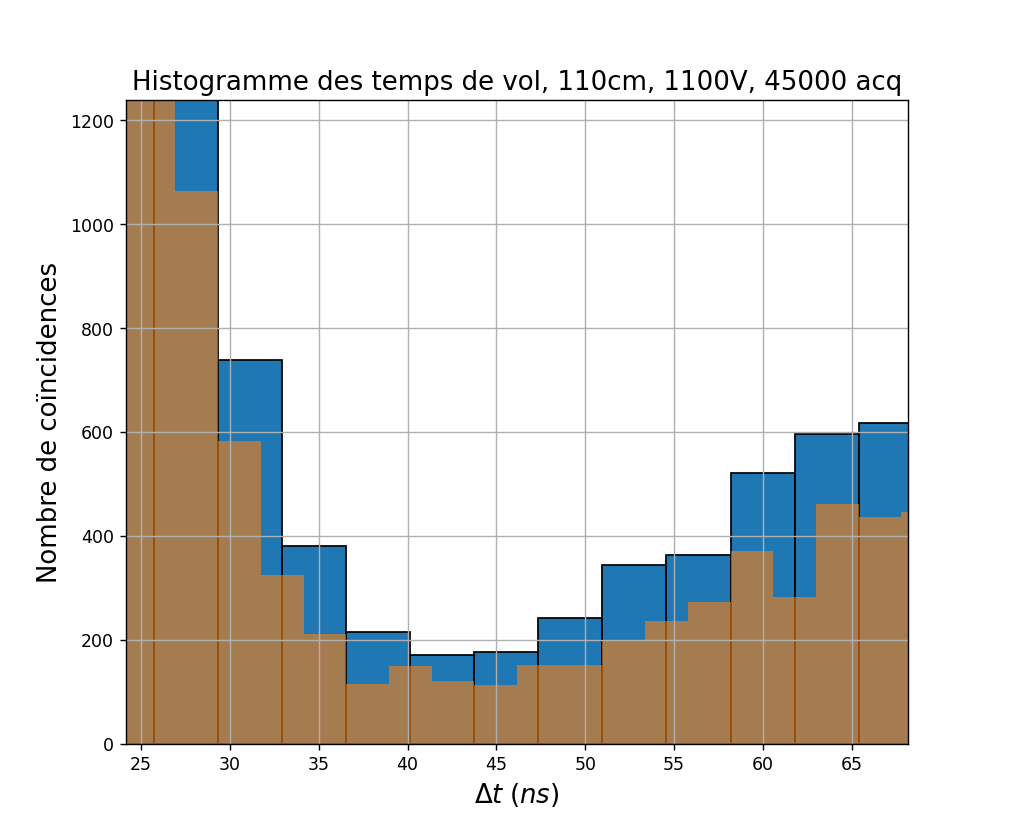

In [180]:
plt.figure()
plt.hist(DT_tot, bins = 100, edgecolor='black')

# Ajouter des titres et labels
plt.title("Histogramme des temps de vol, 110cm, 1100V, 45000 acq", fontsize = 15)
plt.xlabel("$\Delta t\;(ns)$", fontsize = 15)
plt.ylabel("Nombre de coïncidences", fontsize = 15)

# Afficher l'histogramme
#plt.xlim(0,200)
plt.xlim(-10,150)
plt.grid()
#plt.savefig('Histo 110cm 1100V 3000acq')
plt.show() 

In [13]:
def gaussian(x, amp, mu, sigma):
    return amp * np.exp(-(x - mu)**2 / (2 * sigma**2))

<IPython.core.display.Javascript object>


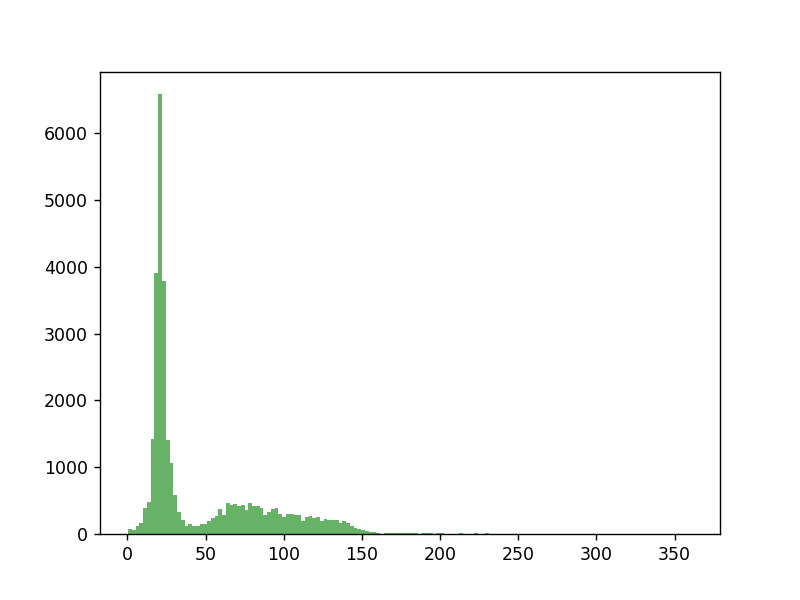

In [14]:
counts, bins, ignored = plt.hist(DT_tot, bins=150, density=False, alpha=0.6, color='g')

In [15]:
bin_centers = 0.5 * (bins[1:] + bins[:-1])
mask = (bin_centers > 0) & (bin_centers < 50)

# Extraire les centres des bins et les valeurs correspondantes
bin_centers_partial = bin_centers[mask]
counts_partial = counts[mask]

In [16]:
initial_guess = [6000, 20, 10]  # Amplitude, mu, sigma (estimation initiale)
popt, pcov = curve_fit(gaussian, bin_centers_partial, counts_partial, p0=initial_guess)

In [17]:
popt

array([6.16636367e+03, 2.09170514e+01, 2.75138261e+00])

In [18]:
np.sqrt(pcov[1,1])

0.15010506273201144

In [19]:
np.sqrt(pcov[2,2])

0.1499934792423231

In [20]:
x_fit = np.linspace(0, 40, 1000)  # Plage des x pour tracer la courbe

<IPython.core.display.Javascript object>


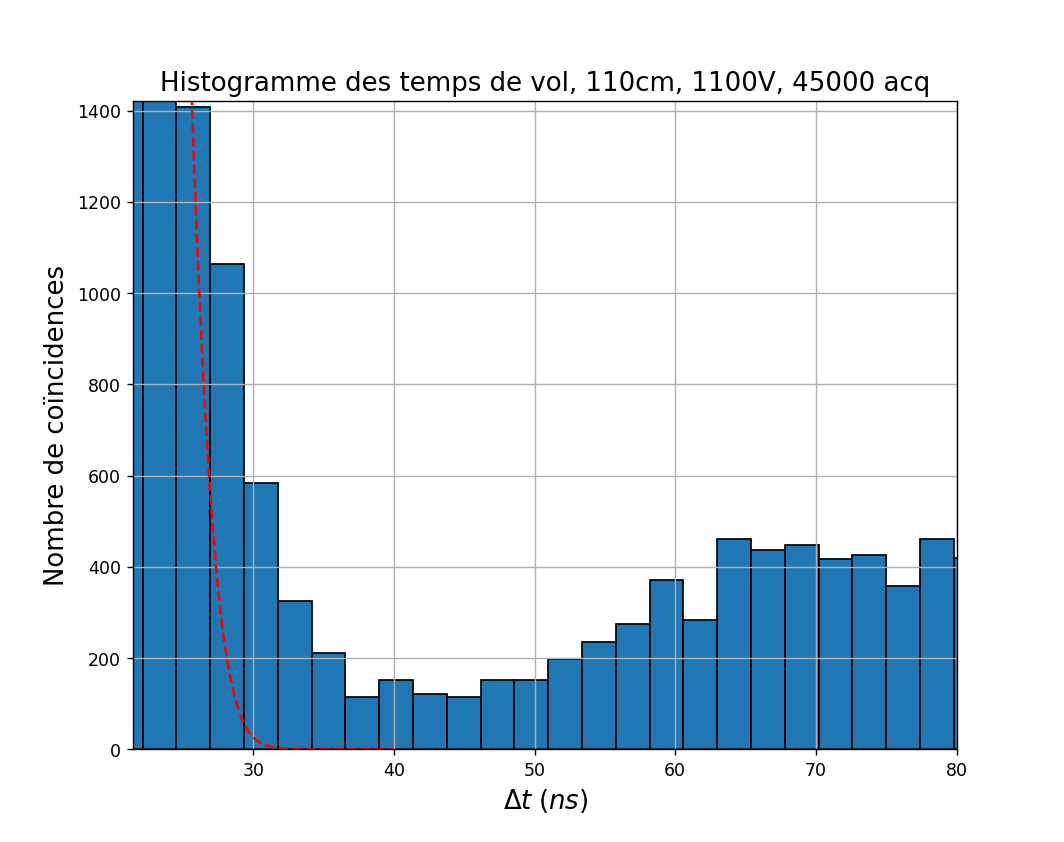

In [119]:
plt.figure()
plt.hist(DT_tot, bins = 150, edgecolor='black')
plt.plot(x_fit, gaussian(x_fit, *popt), 'r--', label='Fit Gaussien')
# Ajouter des titres et labels
plt.title("Histogramme des temps de vol, 110cm, 1100V, 45000 acq", fontsize = 15)
plt.xlabel("$\Delta t\;(ns)$", fontsize = 15)
plt.ylabel("Nombre de coïncidences", fontsize = 15)

# Afficher l'histogramme
#plt.xlim(0,200)
plt.xlim(-10,150)
plt.grid()
#plt.savefig('Histo 110cm 1100V 3000acq')
plt.show()

In [21]:
# Définir des couleurs en fonction de plusieurs plages de valeurs
def color_picker(x):
    if x <= 42 - 3*2.8:
        return 'red'
    elif 42 + 3*2.8 <= x :
        return 'blue'
    else:
        return 'green'

colors = [color_picker(x) for x in bin_centers]

In [190]:
counts, bins, _ = plt.hist(DT_tot, bins=150, density=False, alpha=0.6)

<IPython.core.display.Javascript object>


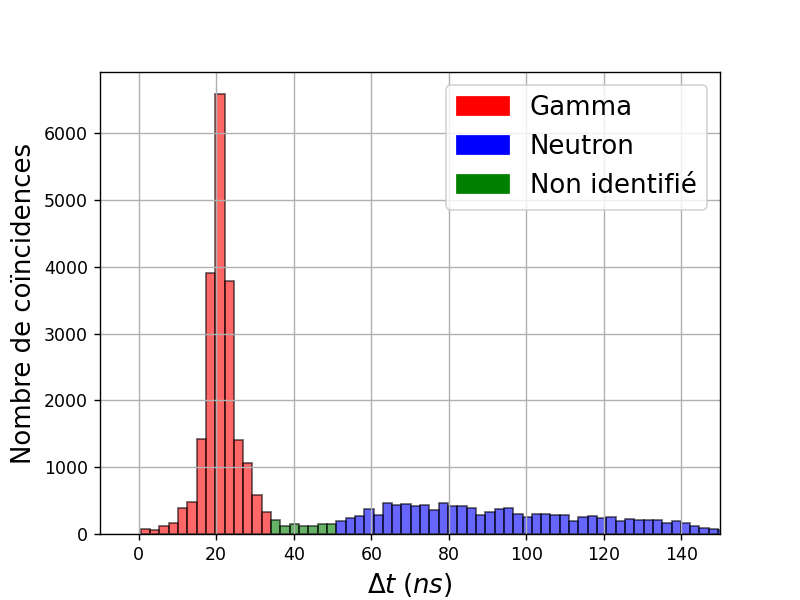

In [28]:
plt.figure()
plt.bar(bin_centers, counts, width=np.diff(bins), color=colors, edgecolor='black', alpha=0.6)
# Ajouter des titres et labels
#plt.title("Histogramme des temps de vol, 110cm, 1100V, 45000 acq", fontsize = 15)
plt.xlabel("$\Delta t\;(ns)$", fontsize = 15)
plt.ylabel("Nombre de coïncidences", fontsize = 15)

red_patch = mpatches.Patch(color='red', label='Gamma')
blue_patch = mpatches.Patch(color='blue', label='Neutron')
green_patch = mpatches.Patch(color='green', label='Non identifié')
plt.legend(handles=[red_patch, blue_patch, green_patch], fontsize = 15)

# Afficher l'histogramme
#plt.xlim(0,200)
plt.xlim(-10,150)
plt.grid()
#plt.savefig('Histo 110cm 1100V 3000acq')
plt.show()

## PSD sur les données du ToF

In [123]:
### Discrimination n/g via le ToF ###

# True = neutron
# False = gamma

#time_n = 50  # ns
time_g = 42  # ns 
#time_n = 45

verity1, verity2 = [], []

for i in range(len(DT1)) :
    if DT1[i] <= time_g :
        verity1.append(False)
        
    else :
        verity1.append(True)
        
for j in range(len(DT2)) :
    if DT2[j] <= time_g :
        verity2.append(False)
        
    else :
        verity2.append(True)

In [124]:
### Sélection des signaux n/g via le ToF ###

neutron1, gamma1 = [], []
neutron2, gamma2 = [], []

t_neutron1, t_gamma1 = [], []
t_neutron2, t_gamma2 = [], []

ToF_n1, ToF_n2 = [], []
ToF_g1, ToF_g2 = [], []

for k in range(len(verity1)) :
    if verity1[k] :
        neutron1.append(DataNE1[2*Verif1[k] + 1])
        t_neutron1.append(DataNE1[2*Verif1[k]])
        ToF_n1.append(dt1[k])
    else :
        gamma1.append(DataNE1[2*Verif1[k] + 1])
        t_gamma1.append(DataNE1[2*Verif1[k]])
        ToF_g1.append(dt1[k])
        
for k in range(len(verity2)) :
    if verity2[k] :
        neutron2.append(DataNE2[2*Verif2[k] + 1])
        t_neutron2.append(DataNE2[2*Verif2[k]])
        ToF_n2.append(dt2[k])
        
    else :
        gamma2.append(DataNE2[2*Verif2[k] + 1])
        t_gamma2.append(DataNE2[2*Verif2[k]])
        ToF_g2.append(dt2[k])

In [125]:
NEUTRON = np.concatenate((np.array(neutron1), np.array(neutron2)))
GAMMA = np.concatenate((np.array(gamma1), np.array(gamma2)))


T_NEUTRON = np.concatenate((np.array(t_neutron1), np.array(t_neutron2)))
T_GAMMA = np.concatenate((np.array(t_gamma1), np.array(t_gamma2)))


TOF_N = np.concatenate((np.array(ToF_n1), np.array(ToF_n2)))
TOF_G = np.concatenate((np.array(ToF_g1), np.array(ToF_g2)))

In [94]:
len(NEUTRON)

12791

In [95]:
len(GAMMA)

20902

In [96]:
len(T_GAMMA)

20902

<IPython.core.display.Javascript object>


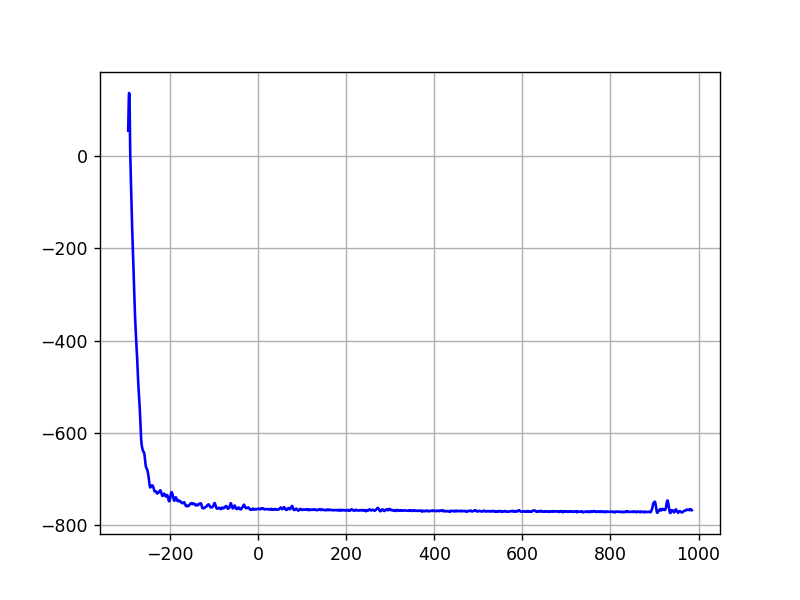

In [102]:
plt.figure()
plt.plot(T_NEUTRON[79], NEUTRON[79], '-b')
plt.grid()
plt.show()

In [417]:
#q = 1

#plt.figure(figsize = (8,7))
#plt.plot(t_neutron1[q], neutron1[q], '-b', label = '$Neutron$')
#plt.plot(t_gamma1[q], gamma1[q], '-r', label = '$Gamma$')
#plt.xlabel('$t\;(ns)$', fontsize = 15)
#plt.ylabel('$A\;(mV)$', fontsize = 15)
#plt.legend(loc = 0, fontsize = 15)
#plt.grid()
#plt.show()

In [126]:
### Selection des indices 20% d'amplitude du pulse ###

n_indice_max = [np.argmax(NEUTRON[k]) for k in range(len(NEUTRON))]
n_amplitude_max = [np.max(NEUTRON[k]) for k in range(len(NEUTRON))] 

n_ind_start_tail=[]
n_ind_level_fast=[]

for k in range(len(NEUTRON)):
    j = 0
    while NEUTRON[k][n_indice_max[k]+j] >= n_amplitude_max[k]*20/100:
        j += 1
    n_ind_start_tail.append(n_indice_max[k]+j)
    i = 0
    while NEUTRON[k][n_indice_max[k]+i]>=n_amplitude_max[k]*20/100:
        i -= 1
    n_ind_level_fast.append(n_indice_max[k]+i)

In [127]:
g_indice_max = [np.argmax(GAMMA[k]) for k in range(len(GAMMA))]
g_amplitude_max = [np.max(GAMMA[k]) for k in range(len(GAMMA))] 

g_ind_start_tail=[]
g_ind_level_fast=[]

for k in range(len(GAMMA)):
    j = 0
    while GAMMA[k][g_indice_max[k]+j] >= g_amplitude_max[k]*20/100:
        j += 1
    g_ind_start_tail.append(g_indice_max[k]+j)
    i = 0
    while GAMMA[k][g_indice_max[k]+i]>=g_amplitude_max[k]*20/100:
        i -= 1
    g_ind_level_fast.append(g_indice_max[k]+i)

In [128]:
'''Intégrer'''

n_Energy_tot = []
n_Energy_tail = []
n_Energy_fast = []
for k in range(len(NEUTRON)):
    n_Energy_tot.append(integrate.simps(NEUTRON[k], T_NEUTRON[k]))
    n_Energy_tail.append(integrate.simps(NEUTRON[k][n_ind_start_tail[k]+75:n_ind_start_tail[k]+720], T_NEUTRON[k][n_ind_start_tail[k]+75:n_ind_start_tail[k]+720]))
    n_Energy_fast.append(integrate.simps(NEUTRON[k][n_ind_level_fast[k]-40:n_ind_level_fast[k]+80], T_NEUTRON[k][n_ind_level_fast[k]-40:n_ind_level_fast[k]+80]))

n_Energy_tot = np.array(n_Energy_tot)
n_Energy_tail = np.array(n_Energy_tail)
n_Energy_fast = np.array(n_Energy_fast)
#print(len(Verif))
#print(len(n_Energy_fast/n_Energy_tail))

In [140]:
'''Intégrer'''

g_Energy_tot = []
g_Energy_tail = []
g_Energy_fast = []
for k in range(len(GAMMA)):
    g_Energy_tot.append(integrate.simps(GAMMA[k], T_GAMMA[k]))
    g_Energy_tail.append(integrate.simps(GAMMA[k][g_ind_start_tail[k]+75:g_ind_start_tail[k]+720], T_GAMMA[k][g_ind_start_tail[k]+75:g_ind_start_tail[k]+720]))
    g_Energy_fast.append(integrate.simps(GAMMA[k][g_ind_level_fast[k]-40:g_ind_level_fast[k]+80], T_GAMMA[k][g_ind_level_fast[k]-40:g_ind_level_fast[k]+80]))

g_Energy_tot = np.array(g_Energy_tot)
g_Energy_tail = np.array(g_Energy_tail)
g_Energy_fast = np.array(g_Energy_fast)
#print(len(GAMMA))
#print(len(g_Energy_fast/g_Energy_tail))

In [141]:
Energy_tail = np.concatenate((g_Energy_tail, n_Energy_tail))
Energy_fast = np.concatenate((g_Energy_fast, n_Energy_fast))
Energy_tot = np.concatenate((g_Energy_tot, n_Energy_tot))

In [142]:
rn_Energy_tail  = n_Energy_tail/n_Energy_tot
rn_Energy_fast  = n_Energy_fast/n_Energy_tot
rg_Energy_tail  = g_Energy_tail/g_Energy_tot
rg_Energy_fast  = g_Energy_fast/g_Energy_tot

### Visualisation PSD avec ToF

In [40]:
xy1 = np.vstack([Energy_tot, Energy_tail])
z1 = gaussian_kde(xy1)(xy1)

<IPython.core.display.Javascript object>


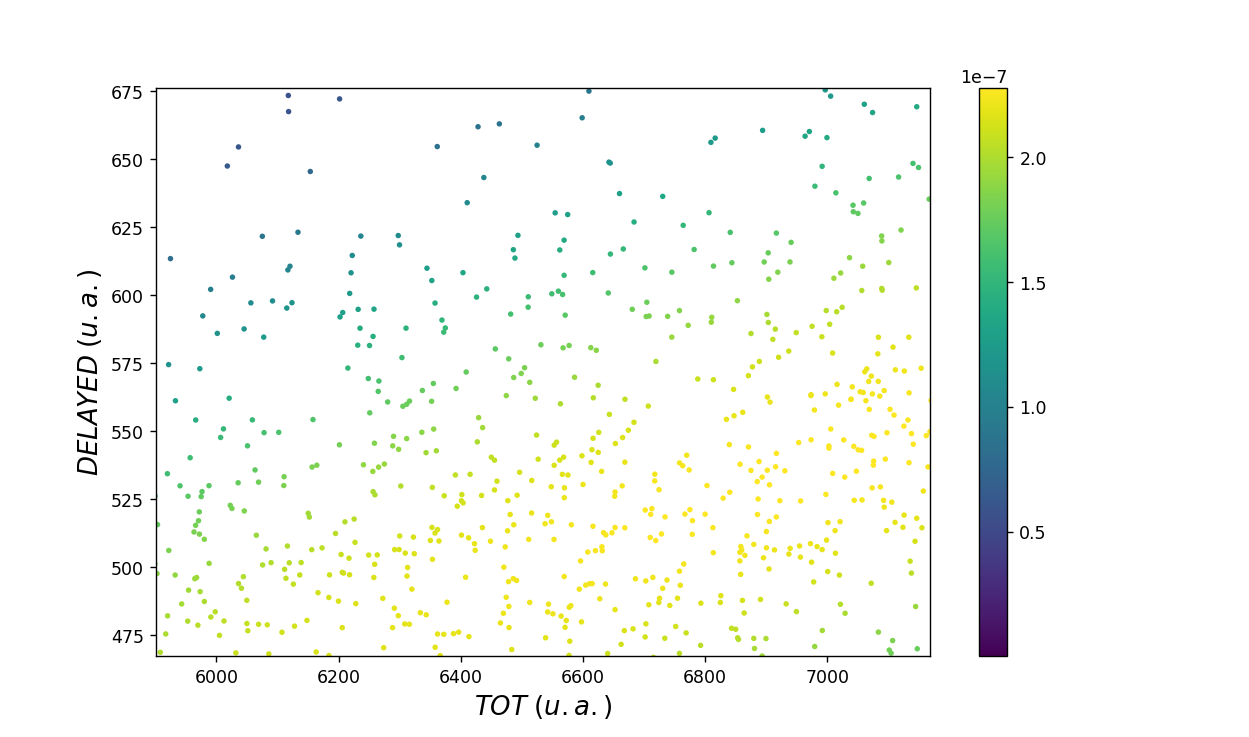

In [46]:
plt.figure()
plt.scatter(Energy_tot, Energy_tail, c = z1, s=10, edgecolor='none', cmap='viridis')
plt.colorbar()
plt.annotate(r'$n$', xy=(16280, 2500),  xycoords='data',xytext=(+10, +50), textcoords='offset points', fontsize=16,
         arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2"))
plt.annotate(r'$\gamma$', xy=(15900, 900),  xycoords='data',xytext=(-10, -70), textcoords='offset points', fontsize=16,
         arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2"))
plt.xlabel('$TOT\;(u.a.)$', fontsize = 15)
plt.ylabel('$DELAYED\;(u.a.)$', fontsize = 15)
plt.ylim(0, 4000)
plt.xlim(2870, 34000)
plt.show()

<IPython.core.display.Javascript object>


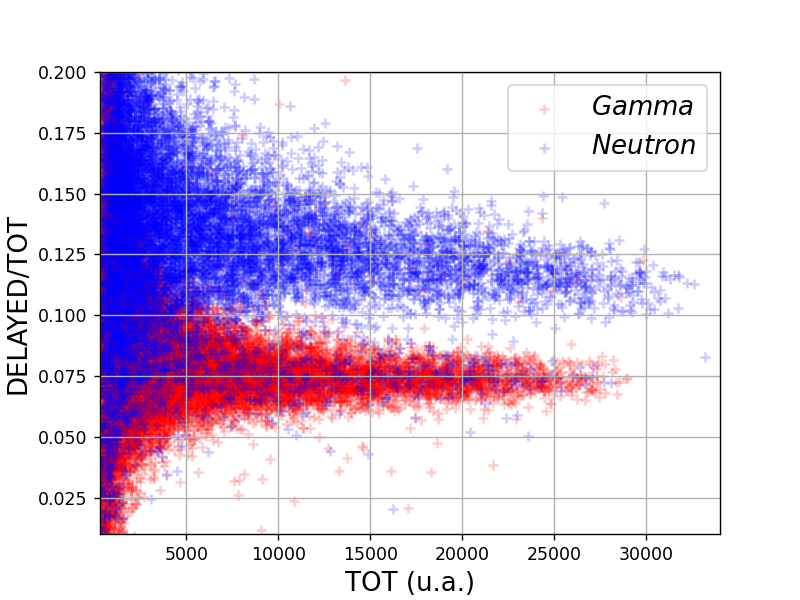

In [21]:
plt.figure()
plt.scatter(g_Energy_tot, rg_Energy_tail, marker = '+', c = 'r', alpha = 0.2, label = '$Gamma$')
plt.scatter(n_Energy_tot, rn_Energy_tail, marker = '+', c = 'b', alpha = 0.2, label = '$Neutron$')
#plt.plot(X, Y1_1, '--k')
#plt.plot(X, Y1_2, '--k')
plt.xlabel('TOT (u.a.)', fontsize = 15)
plt.ylabel('DELAYED/TOT', fontsize = 15)
plt.ylim(0.01, 0.2)
plt.xlim(300, 34000)
plt.legend(loc = 0, fontsize = 15)
plt.grid()
plt.show()

## Energie des $\gamma$

<IPython.core.display.Javascript object>


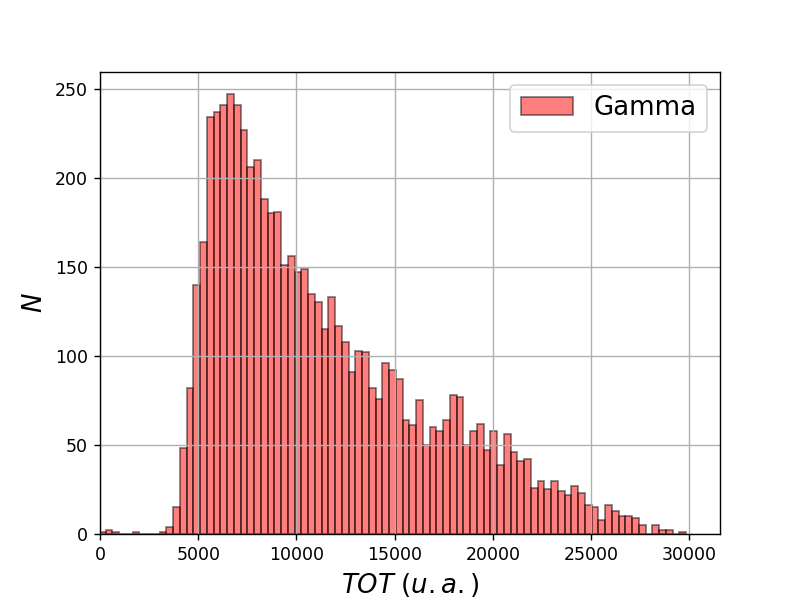

In [143]:
plt.figure()
plt.hist(g_Energy_tot, bins = 100, color = 'red', edgecolor = 'black', alpha = 0.5, label = 'Gamma')
plt.xlabel("$TOT\;(u.a.)$", fontsize = 15)
plt.ylabel("$N$", fontsize = 15)
plt.legend(loc = 0, fontsize = 15)
plt.xlim(0)
plt.grid()
plt.show() 

In [104]:
a1, b1 = 28729.787606791237, 2997.0572015842004
u_a1, u_b1 = 724.2803598350711, 453.70732440968504

In [105]:
#a, b = 1/28729.787606791237, 2997.0572015842004/28729.787606791237
#u_a, u_b = u_a1/a1**2, np.sqrt((u_b1/a1)**2 + (u_a1*b1/a1**2)**2)

In [144]:
a, b = 3.48070794565713e-05, 0.10431880815143048
u_a, u_b = 3.412496790570205e-06, 0.0987577588054094

In [145]:
a,b

(3.48070794565713e-05, 0.10431880815143048)

In [146]:
u_a, u_b

(3.412496790570205e-06, 0.0987577588054094)

In [155]:
g_Energy_MeV = a*g_Energy_tot + b
u_g_Energy_MeV =np.sqrt((u_a*g_Energy_tot)**2 + u_b**2)

<IPython.core.display.Javascript object>


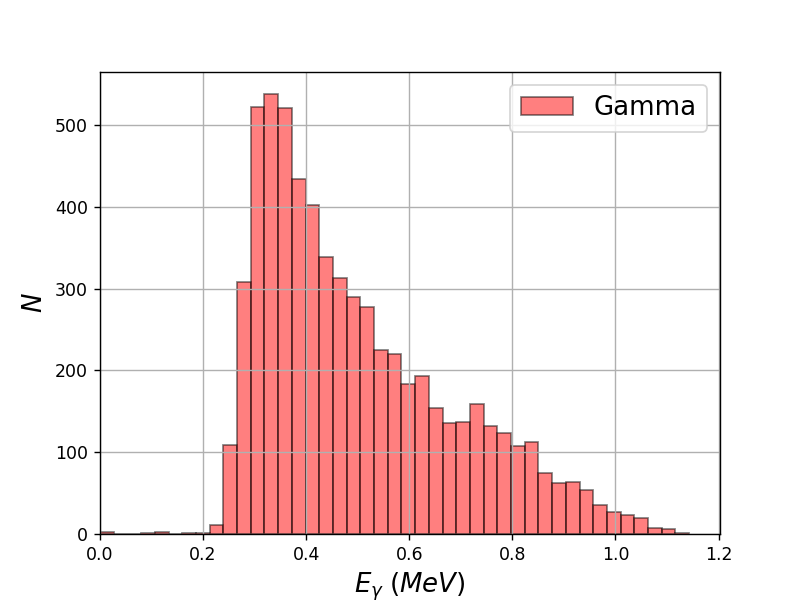

In [178]:
plt.figure()
plt.hist(g_Energy_MeV, bins = 45, color = 'red', edgecolor = 'black', alpha = 0.5, label = 'Gamma')
plt.xlabel("$E_{\gamma}\;(MeV)$", fontsize = 15)
plt.ylabel("$N$", fontsize = 15)
plt.legend(loc = 0, fontsize = 15)
plt.xlim(0)
plt.grid()
plt.show() 

In [169]:
# Créer un histogramme
counts, bins = np.histogram(g_Energy_MeV, bins=80, density = True)
counts_p = counts + np.sqrt(counts)
counts_m = counts - np.sqrt(counts)
# Calculer le milieu des bacs de l'histogramme (centers)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
# Intégrer l'aire sous la courbe de l'histogramme
area = integrate.simps(counts, bin_centers)
area_p = integrate.simps(counts_p, bin_centers)
area_m = integrate.simps(counts_m, bin_centers)

In [170]:
# Créer un histogramme
counts, bins = np.histogram(g_Energy_MeV + u_g_Energy_MeV , bins=80, density = True)
counts_p = counts + np.sqrt(counts)
counts_m = counts - np.sqrt(counts)
# Calculer le milieu des bacs de l'histogramme (centers)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
# Intégrer l'aire sous la courbe de l'histogramme
area_Ep = integrate.simps(counts, bin_centers)
area_p = integrate.simps(counts_p, bin_centers)
area_m = integrate.simps(counts_m, bin_centers)

In [171]:
# Créer un histogramme
counts, bins = np.histogram(g_Energy_MeV - u_g_Energy_MeV , bins=80, density = True)
counts_p = counts + np.sqrt(counts)
counts_m = counts - np.sqrt(counts)
# Calculer le milieu des bacs de l'histogramme (centers)
bin_centers = 0.5 * (bins[1:] + bins[:-1])
# Intégrer l'aire sous la courbe de l'histogramme
area_Em = integrate.simps(counts, bin_centers)
area_p = integrate.simps(counts_p, bin_centers)
area_m = integrate.simps(counts_m, bin_centers)

In [162]:
cum_areas = np.cumsum(counts * np.diff(bins))  # np.diff(bins) est la largeur des bacs

# Trouver l'abscisse où l'aire cumulée atteint 80 % de l'aire totale
target_area = 0.80 * area
index_80_percent = np.searchsorted(cum_areas, target_area)
x_value_80_percent = bin_centers[index_80_percent]

In [163]:
cum_areas_p = np.cumsum(counts_p * np.diff(bins))  # np.diff(bins) est la largeur des bacs

# Trouver l'abscisse où l'aire cumulée atteint 80 % de l'aire totale
target_area_p = 0.80 * area_p
index_80_percent_p = np.searchsorted(cum_areas_p, target_area_p)
x_value_80_percent_p = bin_centers[index_80_percent_p]

In [164]:
cum_areas_m = np.cumsum(counts_m * np.diff(bins))  # np.diff(bins) est la largeur des bacs

# Trouver l'abscisse où l'aire cumulée atteint 80 % de l'aire totale
target_area_m = 0.80 * area_m
index_80_percent_m = np.searchsorted(cum_areas_m, target_area_m)
x_value_80_percent_m = bin_centers[index_80_percent_m]

In [153]:
x_value_80_percent, x_value_80_percent_m, x_value_80_percent_p  # E

(0.6720725090792178, 0.38801288234459885, 0.7318745357601901)

In [165]:
x_value_80_percent, x_value_80_percent_m, x_value_80_percent_p # E + u_E

(0.7664818320997362, 0.4724706886863058, 0.8438531856295863)

In [160]:
x_value_80_percent, x_value_80_percent_m, x_value_80_percent_p # E - u_E

(0.5467146446467595, 0.28703327722546823, 0.6044216151848242)

In [167]:
xmax = (0.4724706886863058 + 0.8438531856295863)/2
xmin = (0.28703327722546823 + 0.6044216151848242)/2

<IPython.core.display.Javascript object>


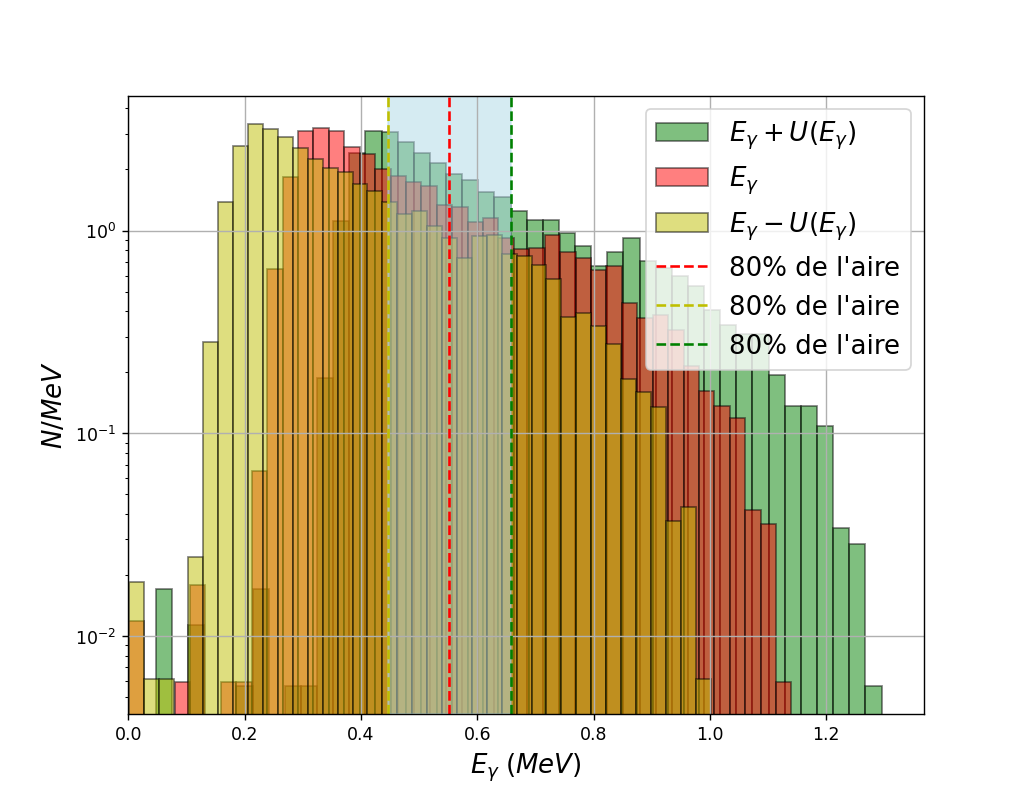

In [179]:
plt.figure()
plt.hist((g_Energy_MeV+u_g_Energy_MeV)/area_Ep, bins=45, alpha=0.5, color='g', edgecolor = 'black', label = '$E_\gamma + U(E_\gamma)$', density = True)
plt.hist(g_Energy_MeV/area, bins=45, alpha=0.5, color='r', edgecolor = 'black', label = '$E_\gamma$', density = True)
plt.hist((g_Energy_MeV-u_g_Energy_MeV)/area_Em, bins=45, alpha=0.5, color='y', edgecolor = 'black', label = '$E_\gamma - U(E_\gamma)$', density = True)
plt.axvline(x=(xmin+xmax)/2, color='r', linestyle='--', label='80% de l\'aire')
plt.axvline(x=xmin, color='y', linestyle='--', label='80% de l\'aire')
plt.axvline(x=xmax, color='g', linestyle='--', label='80% de l\'aire')
plt.axvspan(xmin, xmax, color='lightblue', alpha=0.5)
plt.xlabel("$E_{\gamma}\;(MeV)$", fontsize = 15)
plt.ylabel("$N/MeV$", fontsize = 15)
plt.legend(loc = 0, fontsize = 15)
plt.semilogy()
plt.xlim(0)
plt.grid()
plt.show() 

In [49]:
area

1.0024482704154163

### Détermination de FoM (tail)

In [42]:
rE_n_l_tail, rE_g_l_tail = [], []

for k in range(len(n_Energy_tot)) :
    y1 = rn_Energy_tail[k]
    
    if y1 >= 0.01 and y1 <= 0.3 :
        rE_n_l_tail.append(y1)

for k in range(len(g_Energy_tot)) :
    y2 = rg_Energy_tail[k]

    if y2 >= 0.01 and y2 <= 0.3 :
        rE_g_l_tail.append(y2)

rE_n_tail, rE_g_tail = np.array(rE_n_l_tail), np.array(rE_g_l_tail)

In [43]:
min_bins = min(rE_n_tail.min(), rE_g_tail.min())
max_bins = max(rE_n_tail.max(), rE_g_tail.max())

bins = np.linspace(min_bins, max_bins, 200)

In [44]:
counts_n, bins = np.histogram(rE_n_tail, bins=bins, density=False)
counts_g, bins = np.histogram(rE_g_tail, bins=bins, density=False)
bins = np.linspace(min_bins, max_bins, 200)

In [45]:
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

In [46]:
bin_centers = (bins[:-1] + bins[1:]) / 2

In [47]:
popt_n_PSD_tail, pcov_n_PSD_tail = curve_fit(gaussian, bin_centers, counts_n)
popt_g_PSD_tail, pcov_g_PSD_tail = curve_fit(gaussian, bin_centers, counts_g)

In [48]:
popt_n_PSD_tail[1], np.sqrt(pcov_n_PSD_tail[1,1])

(0.12344968335522506, 0.00037653727428960175)

In [49]:
popt_n_PSD_tail[2], np.sqrt(pcov_n_PSD_tail[2,2])

(0.014533581454101212, 0.00037653727374943054)

In [50]:
popt_g_PSD_tail[1], np.sqrt(pcov_g_PSD_tail[1,1])

(0.07477039829253425, 8.05075181760121e-05)

In [51]:
popt_g_PSD_tail[2], np.sqrt(pcov_g_PSD_tail[2,2])

(0.007610541849440558, 8.050751797370376e-05)

In [52]:
FoM_tail = abs(popt_n_PSD_tail[1] - popt_g_PSD_tail[1])/(abs(popt_n_PSD_tail[2]) + abs(popt_g_PSD_tail[2]))
FoM_tail

2.198293623794308

In [53]:
u_FoM_tail = np.sqrt((np.sqrt(pcov_n_PSD_tail[1,1]))**2 + (pcov_g_PSD_tail[1,1])**2 + (pcov_n_PSD_tail[2,2]**2 + pcov_g_PSD_tail[2,2]**2)*((popt_n_PSD_tail[1] - popt_g_PSD_tail[1])/(popt_n_PSD_tail[2] + popt_g_PSD_tail[2]))**2 )/(popt_n_PSD_tail[2] + popt_g_PSD_tail[2])
u_FoM_tail

0.01700394269153438

In [54]:
x = np.linspace(bins[0], bins[-1], 1000)

<IPython.core.display.Javascript object>


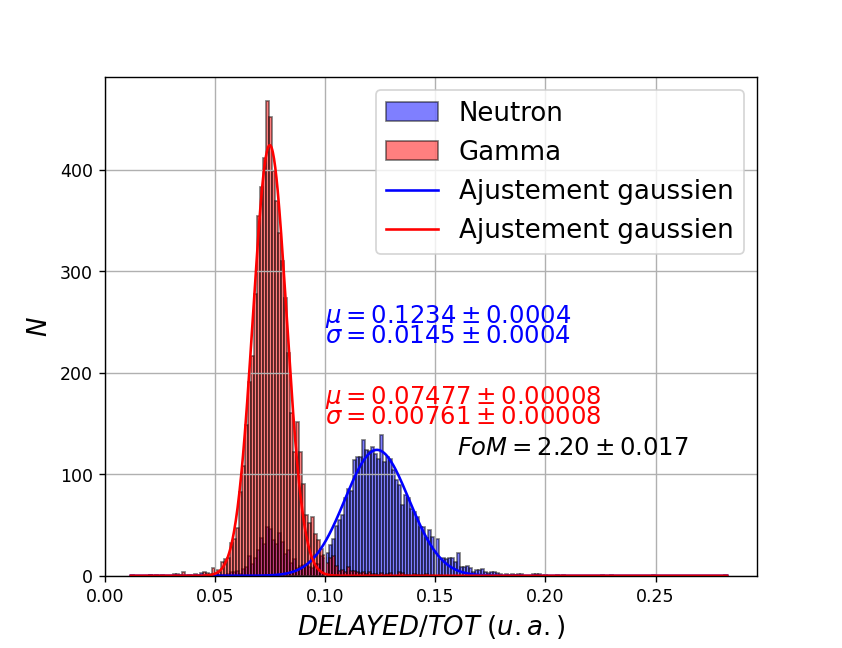

In [126]:
plt.figure()
plt.hist(rE_n_tail, bins = bins, color = 'blue', edgecolor = 'black', alpha = 0.5, label = 'Neutron')
plt.hist(rE_g_tail, bins = bins, color = 'red', edgecolor = 'black', alpha = 0.5, label = 'Gamma')
plt.plot(x, gaussian(x, *popt_n_PSD_tail), '-b', label='Ajustement gaussien')
plt.plot(x, gaussian(x, *popt_g_PSD_tail), '-r', label='Ajustement gaussien')
#plt.text(0.1, 170, '$\mu = 0.1250 \pm 0.0004$\n$\sigma = 0.0147 \pm 0.0004$', c = 'b', fontsize = 14)
#plt.text(0.1, 120, '$\mu = 0.07614 \pm 0.00009$\n$\sigma = 0.00763 \pm 0.00009$', c = 'r', fontsize = 14)
plt.text(0.1,250,r'$\mu = {:.4f}\pm{:.4f}$'.format(abs(popt_n_PSD_tail[1]), np.sqrt(pcov_n_PSD_tail[1, 1])),color='b',fontsize=14)
plt.text(0.1,230,r'$\sigma = {:.4f}\pm{:.4f}$'.format(abs(popt_n_PSD_tail[2]), np.sqrt(pcov_n_PSD_tail[2, 2])),color='b',fontsize=14)
plt.text(0.1,170,r'$\mu = {:.5f}\pm{:.5f}$'.format(abs(popt_g_PSD_tail[1]), np.sqrt(pcov_g_PSD_tail[1, 1])),color='r',fontsize=14)
plt.text(0.1,150,r'$\sigma = {:.5f}\pm{:.5f}$'.format(abs(popt_g_PSD_tail[2]), np.sqrt(pcov_g_PSD_tail[2, 2])),color='r',fontsize=14)
plt.text(0.16, 120,r'$FoM = {:.2f}\pm{:.2}$'.format(FoM_tail, abs(u_FoM_tail)),color='k',fontsize=14)

plt.xlabel("$DELAYED/TOT$", fontsize = 15)
plt.ylabel("$N$", fontsize = 15)
plt.legend(loc = 0, fontsize = 15)
plt.xlim(0)
plt.grid()
plt.show() 

In [55]:
#V_LIM : 200 mV
#END_DELAYED : +500/2 ns

porte_init_delayed = np.array([10, 30, 50, 70, 75,  80, 90, 100, 120])
mu_n = np.array([0.1904, 0.1534, 0.1276, 0.1082, 0.1041, 0.1002, 0.0934, 0.0874,
                0.0768])
u_mu_n = np.array([6e-4, 5e-4, 5e-4, 4e-4, 4e-4, 4e-4, 4e-4, 4e-4, 3e-4])
sig_n = np.array([0.0281, 0.0213, 0.0175, 0.0147, 0.0142, 0.0137, 0.0131, 0.0123,
                 0.0112])
u_sig_n = np.array([6e-4, 5e-4, 5e-4, 4e-4, 4e-4, 4e-4, 4e-4, 4e-4, 3e-4])
mu_g = np.array([0.1257, 0.0912, 0.0726, 0.06086, 0.05852, 0.05634, 0.05245, 
                0.04923, 0.04408])
u_mu_g = np.array([3e-4, 1e-4, 1e-4, 8e-5, 8e-5, 8e-5, 7e-5, 6e-5, 5e-5])
sig_g = np.array([0.0161, 0.0113, 0.0089, 0.00729, 0.00693, 0.00668, 0.00613,
                 0.00558, 0.00488])
u_sig_g = np.array([3e-4, 1e-4, 1e-4, 8e-5, 8e-5, 8e-5, 8e-5, 6e-5, 5e-5])

In [56]:
FOM = abs(mu_n - mu_g)/(sig_n + sig_g)
u_FOM = np.sqrt((u_mu_n)**2 + (u_mu_g)**2 + (u_sig_n**2 + u_sig_g**2)*((mu_n - mu_g)/(sig_n + sig_g))**2 )/(sig_n + sig_g)

<IPython.core.display.Javascript object>


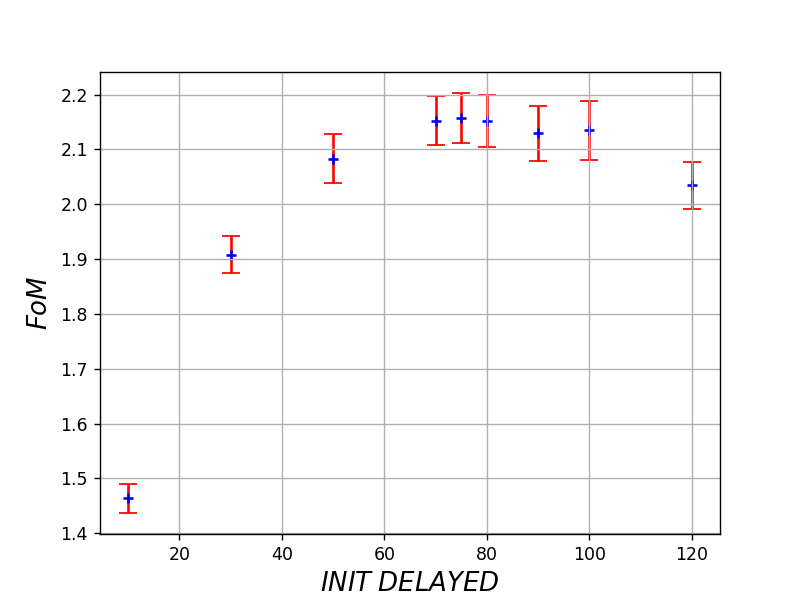

In [404]:
plt.figure()
plt.scatter(porte_init_delayed, FOM, marker = '+', c = 'b')
plt.errorbar(porte_init_delayed, FOM, yerr = u_FOM, fmt = 'none', capsize = 5, ecolor = 'red', zorder = 0)
plt.xlabel('$INIT\;DELAYED$', fontsize = 15)
plt.ylabel('$FoM$', fontsize = 15)
plt.grid()
plt.show()

In [15]:
#V_LIM : 200 mV
#INIT_DELAYED : +75/2 ns

porte_end_delayed = np.array([460, 480, 500, 520, 540, 555, 560, 565, 570, 580, 600, 620, 640, 660, 680, 700, 720, 740])
mu_n1 = np.array([0.0997, 0.1019, 0.1041, 0.1062, 0.1082, 0.1097, 0.1101, 0.1106, 0.1111, 0.1119, 0.1137, 0.1154,
                 0.1171, 0.1188, 0.1204, 0.1219, 0.1235, 0.1250])  ####
u_mu_n1 = np.array([4e-4, 4e-4, 4e-4, 4e-4, 5e-4, 4e-4, 4e-4, 4e-4, 4e-4, 4e-4, 4e-4, 4e-4, 4e-4, 4e-4, 4e-4, 4e-4,
                   4e-4, 4e-4])
sig_n1 = np.array([0.0140, 0.0141, 0.0142, 0.0143, 0.0143, 0.0144, 0.0143, 0.0143, 0.0144, 0.0144, 0.0144, 0.0144,
                  0.0144, 0.0145, 0.0145, 0.0146, 0.0145, 0.0147])
u_sig_n1 = np.array([4e-4, 4e-4, 4e-4, 4e-4, 5e-4, 4e-4, 4e-4, 4e-4, 4e-4, 4e-4, 4e-4, 4e-4, 4e-4, 4e-4, 4e-4, 4e-4,
                    4e-4, 4e-4])
mu_g1 = np.array([0.05512, 0.05683, 0.05852, 0.06019, 0.06179, 0.06297, 0.06334, 0.06373, 0.06411, 0.06486, 0.06634,
                  0.06779, 0.0692, 0.07061, 0.07201, 0.07341, 0.07477, 0.07614])
u_mu_g1 = np.array([8e-5, 9e-5, 8e-5, 9e-5, 9e-5, 9e-5, 9e-5, 8e-5, 9e-5, 9e-5, 9e-5, 9e-5, 1e-4, 9e-5, 9e-5, 9e-5, 
                   9e-5, 9e-5])
sig_g1 = np.array([0.00685, 0.00691, 0.00693, 0.00701, 0.00708, 0.00713, 0.00717, 0.00717, 0.00719, 0.00722, 0.00726,
                  0.00732, 0.0074, 0.00744, 0.00749, 0.00756, 0.00760, 0.00763])
u_sig_g1 = np.array([8e-5, 9e-5, 8e-5, 9e-5, 9e-5, 9e-5, 9e-5, 8e-5, 9e-5, 9e-5, 9e-5, 9e-5, 1e-4, 9e-5, 9e-5, 9e-5,
                    9e-5, 9e-5])

In [16]:
FOM1 = abs(mu_n1 - mu_g1)/(sig_n1 + sig_g1)
u_FOM1 = np.sqrt((u_mu_n1)**2 + (u_mu_g1)**2 + (u_sig_n1**2 + u_sig_g1**2)*((mu_n1 - mu_g1)/(sig_n1 + sig_g1))**2 )/(sig_n1 + sig_g1)

In [21]:
FOM1[-2], u_FOM1[-2]

(2.2049773755656106, 0.044917101164054174)

<IPython.core.display.Javascript object>


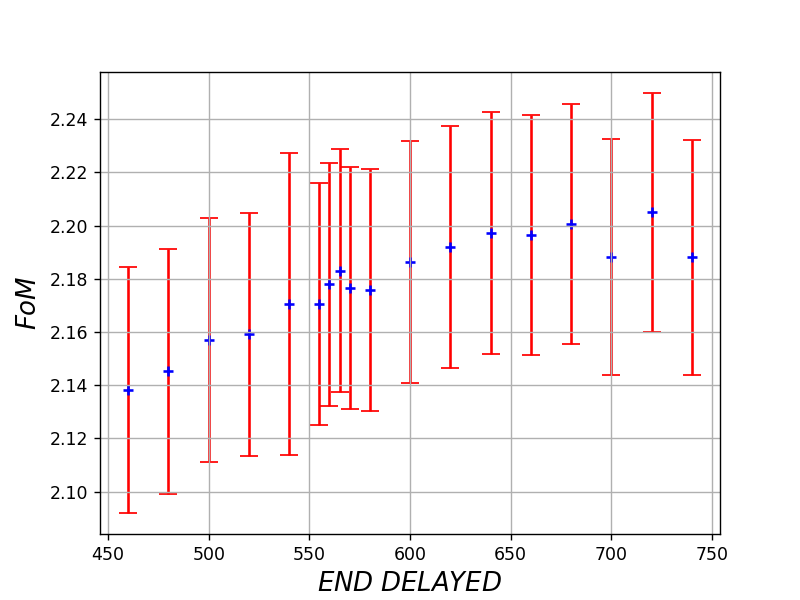

In [17]:
plt.figure()
plt.scatter(porte_end_delayed, FOM1, marker = '+', c = 'b')
plt.errorbar(porte_end_delayed, FOM1, yerr = u_FOM1, fmt = 'none', capsize = 5, ecolor = 'red', zorder = 0)
plt.xlabel('$END\;DELAYED$', fontsize = 15)
plt.ylabel('$FoM$', fontsize = 15)
plt.grid()
plt.show()

### Détermination de FoM (fast)

<IPython.core.display.Javascript object>


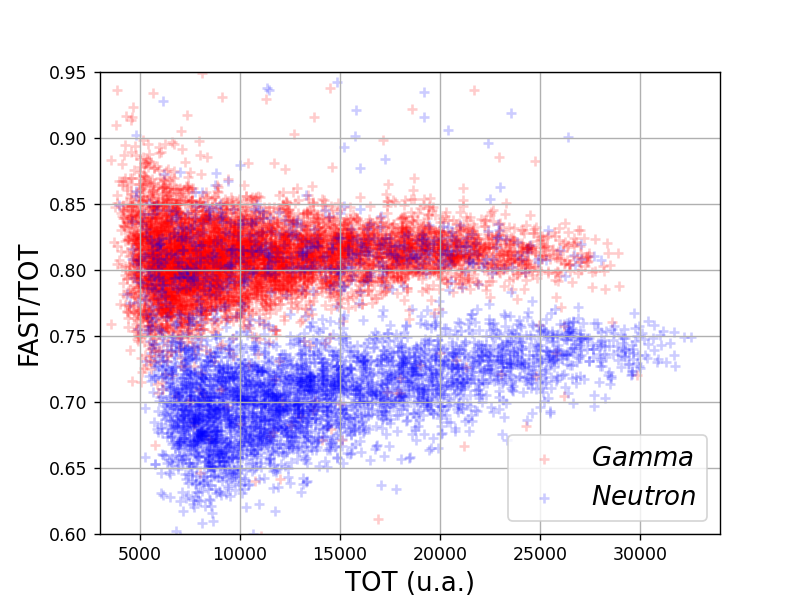

In [452]:
plt.figure()
plt.scatter(g_Energy_tot, rg_Energy_fast, marker = '+', c = 'r', alpha = 0.2, label = '$Gamma$')
plt.scatter(n_Energy_tot, rn_Energy_fast, marker = '+', c = 'b', alpha = 0.2, label = '$Neutron$')
#plt.plot(X, Y1_1, '--k')
#plt.plot(X, Y1_2, '--k')
plt.xlabel('TOT (u.a.)', fontsize = 15)
plt.ylabel('FAST/TOT', fontsize = 15)
plt.ylim(0.6, 0.95)
plt.xlim(3000, 34000)
plt.legend(loc = 0, fontsize = 15)
plt.grid()
plt.show()

In [57]:
rE_n_l_fast, rE_g_l_fast = [], []

for k in range(len(n_Energy_tot)) :
    y1 = rn_Energy_fast[k]
    
    if y1 >= 0.6 and y1 <= 0.93 :
        rE_n_l_fast.append(y1)

for k in range(len(g_Energy_tot)) :
    y2 = rg_Energy_fast[k]

    if y2 >= 0.6 and y2 <= 0.93 :
        rE_g_l_fast.append(y2)

rE_n_fast, rE_g_fast = np.array(rE_n_l_fast), np.array(rE_g_l_fast)

In [58]:
min_bins = min(rE_n_fast.min(), rE_g_fast.min())
max_bins = max(rE_n_fast.max(), rE_g_fast.max())

bins = np.linspace(min_bins, max_bins, 100)

In [59]:
counts_n, bins = np.histogram(rE_n_fast, bins=bins, density=False)
counts_g, bins = np.histogram(rE_g_fast, bins=bins, density=False)
bins = np.linspace(min_bins, max_bins, 100)

In [60]:
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

In [61]:
bin_centers = (bins[:-1] + bins[1:]) / 2

In [62]:
popt_n_PSD_fast, pcov_n_PSD_fast = curve_fit(gaussian, bin_centers, counts_n)
popt_g_PSD_fast, pcov_g_PSD_fast = curve_fit(gaussian, bin_centers, counts_g)

In [63]:
FoM_fast = abs(popt_n_PSD_fast[1] - popt_g_PSD_fast[1])/(abs(popt_n_PSD_fast[2]) + abs(popt_g_PSD_fast[2]))
FoM_fast

1.9364768153012923

In [64]:
u_FoM_fast = np.sqrt((np.sqrt(pcov_n_PSD_fast[1,1]))**2 + (pcov_g_PSD_fast[1,1])**2 + (pcov_n_PSD_fast[2,2]**2 + pcov_g_PSD_fast[2,2]**2)*((popt_n_PSD_fast[1] - popt_g_PSD_fast[1])/(popt_n_PSD_fast[2] + popt_g_PSD_fast[2]))**2 )/(abs(popt_n_PSD_fast[2]) + abs(popt_g_PSD_fast[2]))
u_FoM_fast

0.018169959593724354

In [461]:
x = np.linspace(bins[0], bins[-1], 1000)

<IPython.core.display.Javascript object>


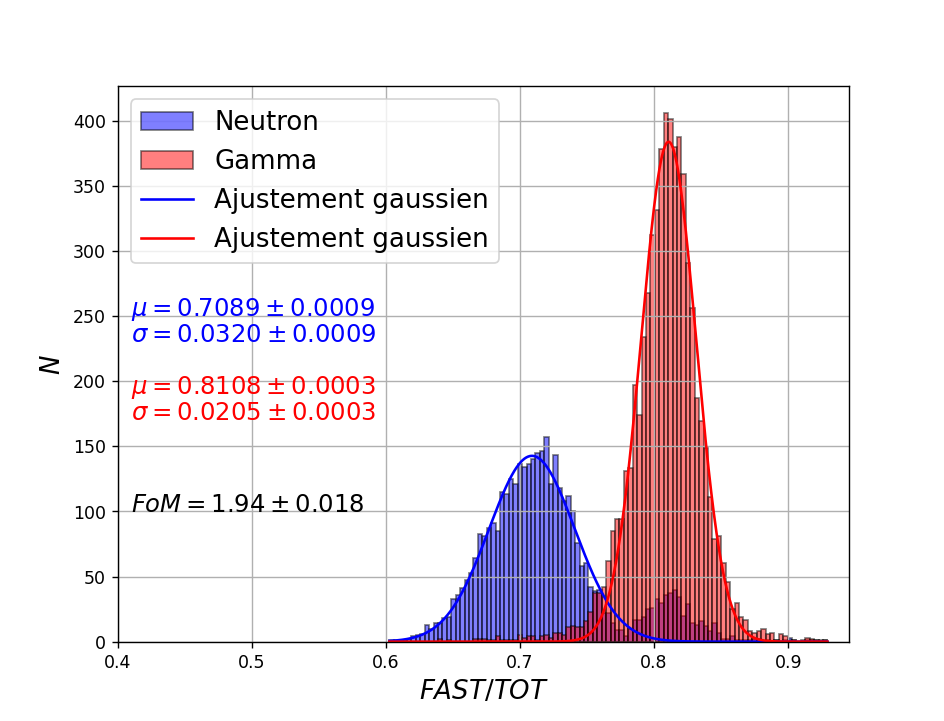

In [466]:
plt.figure()
plt.hist(rE_n_fast, bins = bins, color = 'blue', edgecolor = 'black', alpha = 0.5, label = 'Neutron')
plt.hist(rE_g_fast, bins = bins, color = 'red', edgecolor = 'black', alpha = 0.5, label = 'Gamma')
plt.plot(x, gaussian(x, *popt_n_PSD_fast), '-b', label='Ajustement gaussien')
plt.plot(x, gaussian(x, *popt_g_PSD_fast), '-r', label='Ajustement gaussien')
#plt.text(0.1, 170, '$\mu = 0.1250 \pm 0.0004$\n$\sigma = 0.0147 \pm 0.0004$', c = 'b', fontsize = 14)
#plt.text(0.1, 120, '$\mu = 0.07614 \pm 0.00009$\n$\sigma = 0.00763 \pm 0.00009$', c = 'r', fontsize = 14)
plt.text(0.41,250,r'$\mu = {:.4f}\pm{:.4f}$'.format(abs(popt_n_PSD_fast[1]), np.sqrt(pcov_n_PSD_fast[1, 1])),color='b',fontsize=14)
plt.text(0.41,230,r'$\sigma = {:.4f}\pm{:.4f}$'.format(abs(popt_n_PSD_fast[2]), np.sqrt(pcov_n_PSD_fast[2, 2])),color='b',fontsize=14)
plt.text(0.41,190,r'$\mu = {:.4f}\pm{:.4f}$'.format(abs(popt_g_PSD_fast[1]), np.sqrt(pcov_g_PSD_fast[1, 1])),color='r',fontsize=14)
plt.text(0.41,170,r'$\sigma = {:.4f}\pm{:.4f}$'.format(abs(popt_g_PSD_fast[2]), np.sqrt(pcov_g_PSD_fast[2, 2])),color='r',fontsize=14)
plt.text(0.41,100,r'$FoM = {:.2f}\pm{:.2}$'.format(FoM_fast, abs(u_FoM_fast)),color='k',fontsize=14)

plt.xlabel("$FAST/TOT$", fontsize = 15)
plt.ylabel("$N$", fontsize = 15)
plt.legend(loc = 0, fontsize = 15)
plt.xlim(0.4)
plt.grid()
plt.show() 

In [76]:
#V_LIM : 200 mV
#END_FAST : +80/2 ns

porte_init_fast = np.array([30, 10, 0, -10, -20, -30, -40, -50, -60])
mu_n1 = np.array([0.3786, 0.6250, 0.6806, 0.6921, 0.693, 0.693, 0.692, 0.693, 0.693])  
u_mu_n1 = np.array([5e-4, 9e-4, 9e-4, 8e-4, 1e-3, 1e-3, 1e-3, 1e-3, 1e-3])
sig_n1 = np.array([0.0338, 0.0295, 0.0327, 0.0335, 0.034, 0.033, 0.033, 0.033, 0.033])
u_sig_n1 = np.array([5e-4, 9e-4, 9e-4, 8e-4, 1e-3, 1e-3, 1e-3, 1e-3, 1e-3])
mu_g1 = np.array([0.3977, 0.7125, 0.7850, 0.7983, 0.7989, 0.7990, 0.7989, 0.7990, 0.7989])
u_mu_g1 = np.array([7e-4, 3e-4, 3e-4, 4e-4, 3e-4, 3e-4, 3e-4, 3e-4, 3e-4])
sig_g1 = np.array([0.0427, 0.0198, 0.0208, 0.0215, 0.0216, 0.0215, 0.0215, 0.0214, 0.0215])
u_sig_g1 = np.array([7e-4, 3e-4, 3e-4, 4e-4, 3e-4, 3e-4, 3e-4, 3e-4, 3e-4])

In [77]:
len(porte_init_fast)

9

In [79]:
FOM1 = abs(mu_n1 - mu_g1)/(sig_n1 + sig_g1)
u_FOM1 = np.sqrt((u_mu_n1)**2 + (u_mu_g1)**2 + (u_sig_n1**2 + u_sig_g1**2)*((mu_n1 - mu_g1)/(sig_n1 + sig_g1))**2 )/(sig_n1 + sig_g1)

In [80]:
len(FOM1)

9

<IPython.core.display.Javascript object>


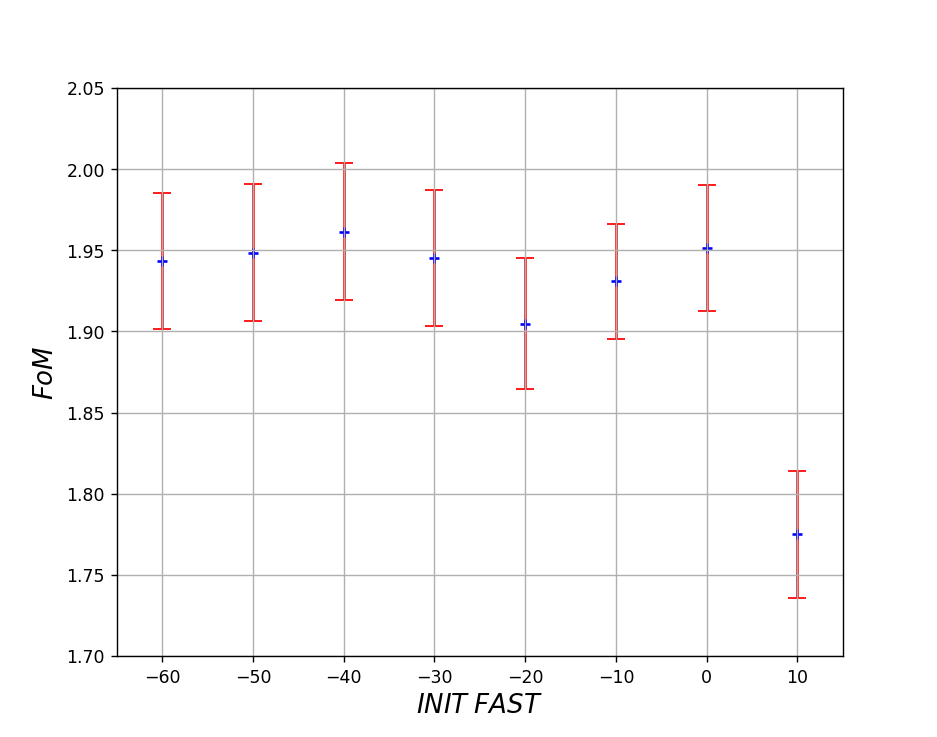

In [86]:
plt.figure()
plt.scatter(porte_init_fast, FOM1, marker = '+', c = 'b')
plt.errorbar(porte_init_fast, FOM1, yerr = u_FOM1, fmt = 'none', capsize = 5, ecolor = 'red', zorder = 0)
plt.xlabel('$INIT\;FAST$', fontsize = 15)
plt.ylabel('$FoM$', fontsize = 15)
plt.xlim(-65, 15)
plt.ylim(1.7, 2.05)
plt.grid()
plt.show()

In [68]:
popt_n_PSD_fast[1], np.sqrt(pcov_n_PSD_fast[1,1])

(0.6925889988433589, 0.0009982638574927642)

In [69]:
popt_n_PSD_fast[2], np.sqrt(pcov_n_PSD_fast[2,2])

(-0.03341975017980853, 0.001001025624344464)

In [70]:
popt_g_PSD_fast[1], np.sqrt(pcov_g_PSD_fast[1,1])

(0.7989799074559014, 0.0003107268790493621)

In [71]:
popt_g_PSD_fast[2], np.sqrt(pcov_g_PSD_fast[2,2])

(-0.021520700318685766, 0.00031072687946934863)

In [72]:
#V_LIM : 200 mV
#INIT_FAST : -40/2 ns

porte_end_fast = np.array([70, 75, 80, 85, 90, 100])
mu_n1 = np.array([0.653, 0.674, 0.692, 0.7089, 0.7230, 0.7464])  
u_mu_n1 = np.array([1e-3, 1e-3, 1e-3, 9e-4, 9e-4, 9e-4])
sig_n1 = np.array([0.038, 0.035, 0.033, 0.0320, 0.0305, 0.0283])
u_sig_n1 = np.array([1e-3, 1e-3, 1e-3, 9e-4, 9e-4, 9e-4])
mu_g1 = np.array([0.7659, 0.7842, 0.7989, 0.8108, 0.8205, 0.8354])
u_mu_g1 = np.array([3e-4, 3e-4, 3e-4, 3e-4, 3e-4, 3e-4])
sig_g1 = np.array([0.0251, 0.0231, 0.0215, 0.0205, 0.0199, 0.0191])
u_sig_g1 = np.array([3e-4, 3e-4, 3e-4, 3e-4, 3e-4, 3e-4])

In [73]:
FOM1 = abs(mu_n1 - mu_g1)/(sig_n1 + sig_g1)
u_FOM1 = np.sqrt((u_mu_n1)**2 + (u_mu_g1)**2 + (u_sig_n1**2 + u_sig_g1**2)*((mu_n1 - mu_g1)/(sig_n1 + sig_g1))**2 )/(sig_n1 + sig_g1)

<IPython.core.display.Javascript object>


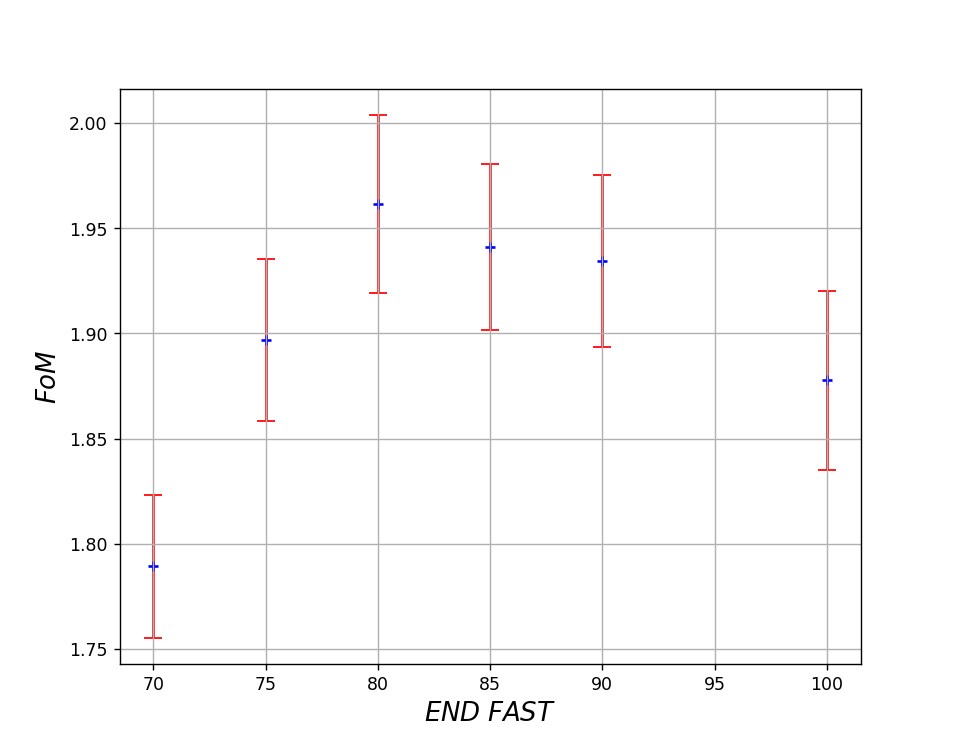

In [74]:
plt.figure()
plt.scatter(porte_end_fast, FOM1, marker = '+', c = 'b')
plt.errorbar(porte_end_fast, FOM1, yerr = u_FOM1, fmt = 'none', capsize = 5, ecolor = 'red', zorder = 0)
plt.xlabel('$END\;FAST$', fontsize = 15)
plt.ylabel('$FoM$', fontsize = 15)
plt.grid()
plt.show()

## Cut

<IPython.core.display.Javascript object>


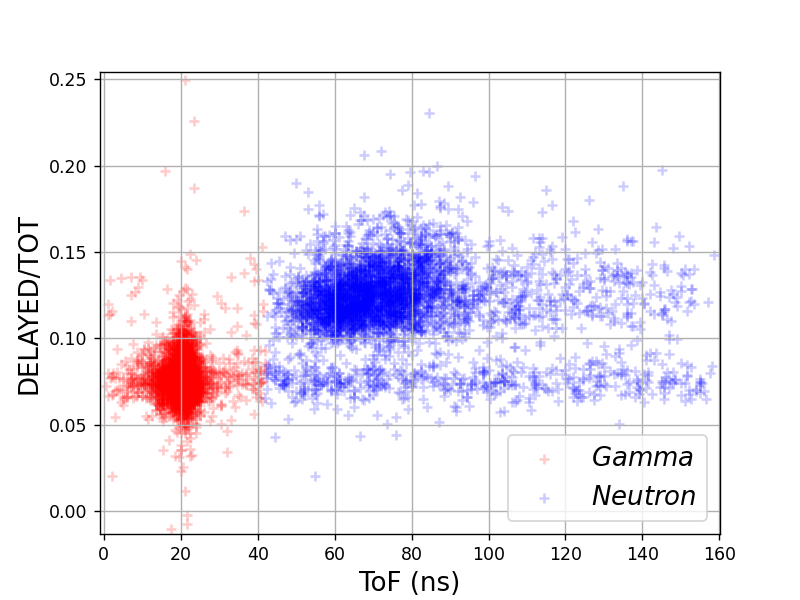

In [71]:
### Histogramme 2D Delayed/Tot VS ToF ###

plt.figure()
plt.scatter(TOF_G, rg_Energy_tail, marker = '+', c = 'r', alpha = 0.2, label = '$Gamma$')
plt.scatter(TOF_N, rn_Energy_tail, marker = '+', c = 'b', alpha = 0.2, label = '$Neutron$')
#plt.plot(X, Y1_1, '--k')
#plt.plot(X, Y1_2, '--k')
plt.xlabel('ToF (ns)', fontsize = 15)
plt.ylabel('DELAYED/TOT', fontsize = 15)
plt.ylim(0.01, 0.25)
plt.xlim(0, 160)
plt.legend(loc = 0, fontsize = 15)
plt.grid()
plt.show()

In [86]:
### Cut ###

TOF_N_CUTl = []
RE_Nl = []
E_N_tot_cutl = []

for k in range(len(TOF_N)) :
    rE_n = rn_Energy_tail[k]
    if TOF_N[k] > 38 and rE_n > 0.0933 :
        TOF_N_CUTl.append(TOF_N[k])
        RE_Nl.append(rE_n)
        E_N_tot_cutl.append(n_Energy_tot[k])

TOF_N_CUT, RE_N = np.array(TOF_N_CUTl), np.array(RE_Nl)
TOF_G_CUT, RE_G = np.array(TOF_G), rg_Energy_tail
TOF_CUT= np.concatenate((TOF_N_CUT, TOF_G))
E_N_TOT_CUT = np.array(E_N_tot_cutl)

<IPython.core.display.Javascript object>


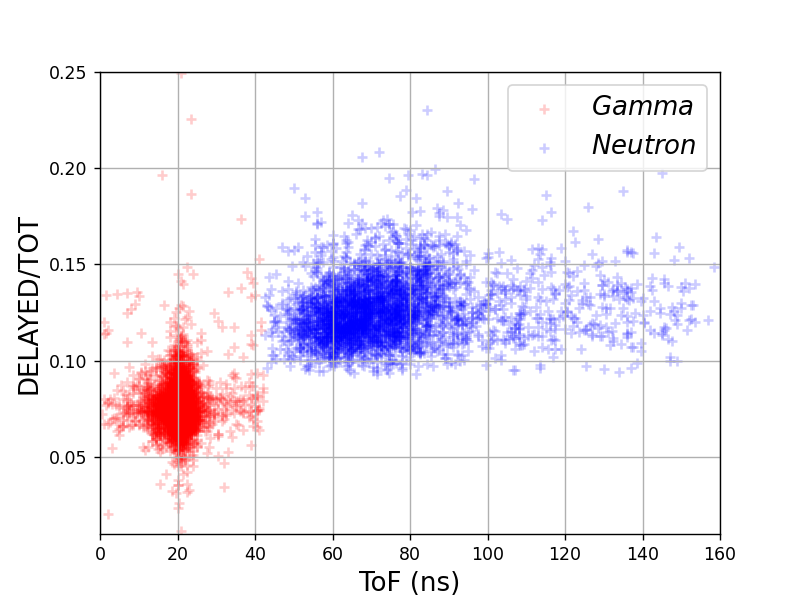

In [73]:
plt.figure()
plt.scatter(TOF_G, rg_Energy_tail, marker = '+', c = 'r', alpha = 0.2, label = '$Gamma$')
plt.scatter(TOF_N_CUT, RE_N, marker = '+', c = 'b', alpha = 0.2, label = '$Neutron$')
#plt.plot(X, Y1_1, '--k')
#plt.plot(X, Y1_2, '--k')
plt.xlabel('ToF (ns)', fontsize = 15)
plt.ylabel('DELAYED/TOT', fontsize = 15)
plt.ylim(0.01, 0.25)
plt.xlim(0, 160)
plt.legend(loc = 0, fontsize = 15)
plt.grid()
plt.show()

<IPython.core.display.Javascript object>


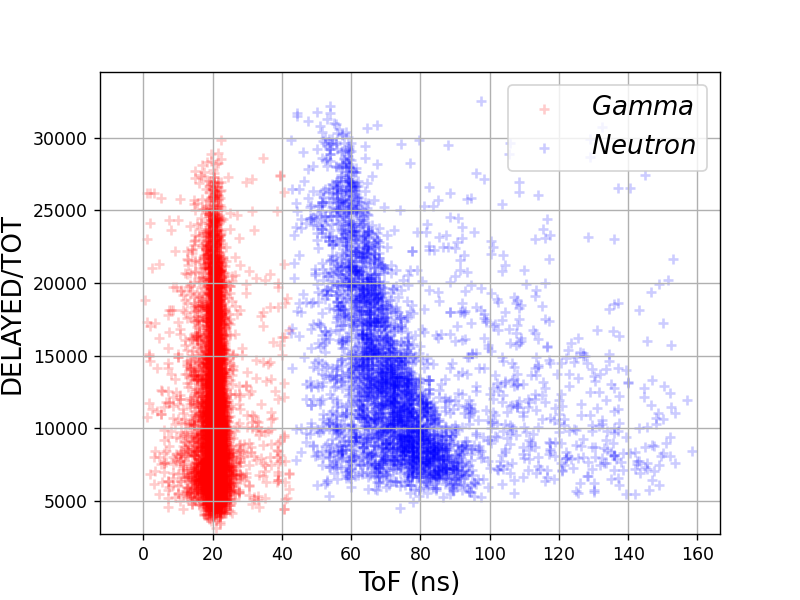

In [83]:
plt.figure()
plt.scatter(TOF_G, g_Energy_tot, marker = '+', c = 'r', alpha = 0.2, label = '$Gamma$')
plt.scatter(TOF_N_CUT, E_N_TOT_CUT, marker = '+', c = 'b', alpha = 0.2, label = '$Neutron$')
#plt.plot(X, Y1_1, '--k')
#plt.plot(X, Y1_2, '--k')
plt.xlabel('ToF (ns)', fontsize = 15)
plt.ylabel('TOT', fontsize = 15)
#plt.ylim(0.01, 0.25)
#plt.xlim(0, 160)
plt.legend(loc = 0, fontsize = 15)
plt.grid()
plt.show()

In [257]:
X_PSD = np.linspace(3200, 34000, 40000)
x1, y1 = 1.043e4, 0.1038
x2, y2 = 2.71e4, 0.0891
a_PSD = (y2 - y1)/(x2 - x1)
b_PSD = 0.5*(y1 + y2 - a_PSD*(x1 + x2))

Y_PSD = a_PSD*X_PSD + b_PSD

<IPython.core.display.Javascript object>


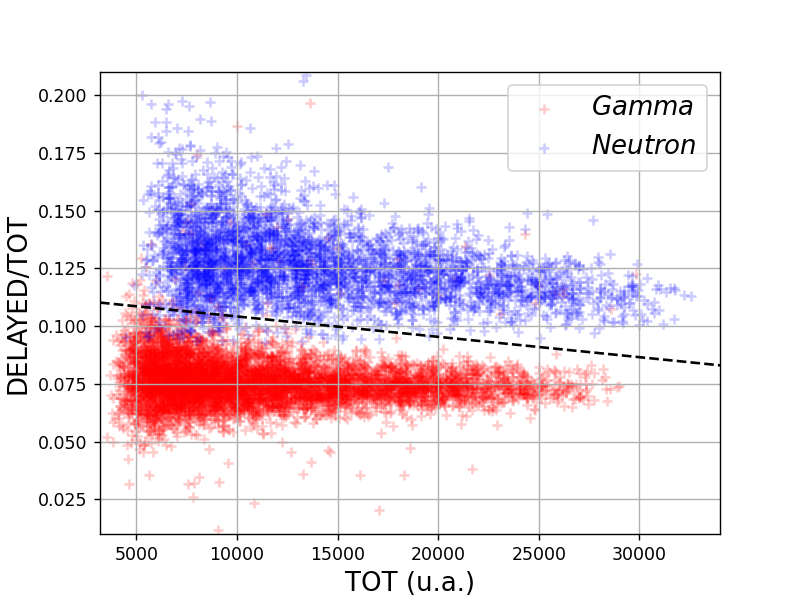

In [264]:
plt.figure()
plt.plot(X_PSD, Y_PSD, '--k')
plt.scatter(g_Energy_tot, rg_Energy_tail, marker = '+', c = 'r', alpha = 0.2, label = '$Gamma$')
plt.scatter(E_N_TOT_CUT, RE_N, marker = '+', c = 'b', alpha = 0.2, label = '$Neutron$')
#plt.plot(X, Y1_1, '--k')
#plt.plot(X, Y1_2, '--k')
plt.xlabel('TOT (u.a.)', fontsize = 15)
plt.ylabel('DELAYED/TOT', fontsize = 15)
plt.ylim(0.01, 0.21)
plt.xlim(3200, 34000)
plt.legend(loc = 0, fontsize = 15)
plt.grid()
plt.show()

In [342]:
N_y, N_n = 0, 0
G_y, G_n = 0, 0

TOT_lim1, TOT_lim2 = 15000, 35000

for k in range(len(g_Energy_tot)) :
    y = a_PSD*g_Energy_tot[k] + b_PSD
    
    if rg_Energy_tail[k] < y and TOT_lim1 < g_Energy_tot[k] <= TOT_lim2:
        G_y += 1
        
    if rg_Energy_tail[k] > y and TOT_lim1 < g_Energy_tot[k] <= TOT_lim2:
        G_n += 1

for k in range(len(E_N_TOT_CUT)) :
    y = a_PSD*E_N_TOT_CUT[k] + b_PSD
    
    if RE_N[k] > y and TOT_lim1 < E_N_TOT_CUT[k] <= TOT_lim2:
        N_y += 1
        
    if RE_N[k] < y and TOT_lim1 < E_N_TOT_CUT[k] <= TOT_lim2:
        N_n += 1

In [343]:
ratio_N, ratio_G = N_y/(N_y+N_n), G_y/(G_y+G_n)
U_N_y, U_N_n = np.sqrt(N_y), np.sqrt(N_n)
U_G_y, U_G_n = np.sqrt(G_y), np.sqrt(G_n)
U_ratio_N = np.sqrt((U_N_y*N_n/(N_y+N_n)**2)**2 + (U_N_n*N_y/(N_y+N_n)**2)**2)
U_ratio_G = np.sqrt((U_G_y*G_n/(G_y+G_n)**2)**2 + (U_G_n*G_y/(G_y+G_n)**2)**2)

In [344]:
a*TOT_lim1 + b, np.sqrt((u_a*TOT_lim1)**2 + (u_b)**2)

(0.626425, 0.020725779839522073)

In [345]:
a*TOT_lim2 + b, np.sqrt((u_a*TOT_lim2)**2 + (u_b)**2)

(1.322566589131426, 0.034634456739964896)

In [346]:
ratio_N, ratio_G

(0.9959016393442623, 0.986046511627907)

In [347]:
U_ratio_N, U_ratio_G

(0.0018290829234115502, 0.0030235826733012662)

In [355]:
rE_n_l, rE_g_l = [], []

for k in range(len(E_N_TOT_CUT)) :
    y1 = RE_N[k]
    
    if y1 >= 0.01 and y1 <= 0.25 :
        rE_n_l.append(y1)

for k in range(len(g_Energy_tot)) :
    y2 = rg_Energy_tail[k]

    if y2 >= 0.01 and y2 <= 0.25 :
        rE_g_l.append(y2)

rE_n_tail_CUT, rE_g_tail_CUT = np.array(rE_n_l), np.array(rE_g_l)

In [357]:
min_bins = min(rE_n.min(), rE_g_tail_CUT.min())
max_bins = max(rE_n.max(), rE_g_tail_CUT.max())

bins = np.linspace(min_bins, max_bins, 200)

In [358]:
counts_n, bins = np.histogram(rE_n_tail_CUT, bins=bins, density=False)
counts_g, bins = np.histogram(rE_g_tail_CUT, bins=bins, density=False)

In [359]:
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

In [360]:
bin_centers = (bins[:-1] + bins[1:]) / 2

In [361]:
popt_n_PSD_tail_CUT, pcov_n_PSD_tail_CUT = curve_fit(gaussian, bin_centers, counts_n)
popt_g_PSD_tail_CUT, pcov_g_PSD_tail_CUT = curve_fit(gaussian, bin_centers, counts_g)

In [362]:
popt_n_PSD_tail_CUT[1], np.sqrt(pcov_n_PSD_tail_CUT[1,1])

(0.12359612655728702, 0.00020747505521895776)

In [363]:
popt_n_PSD_tail_CUT[2], np.sqrt(pcov_n_PSD_tail_CUT[2,2])

(0.013972105912070949, 0.00020747505494951061)

In [364]:
popt_g_PSD_tail_CUT[1], np.sqrt(pcov_g_PSD_tail_CUT[1,1])

(0.07477134882472636, 8.47530057068452e-05)

In [365]:
popt_g_PSD_tail_CUT[2], np.sqrt(pcov_g_PSD_tail_CUT[2,2])

(0.007598266753535211, 8.475300562875176e-05)

In [366]:
FoM_tail_CUT = abs(popt_n_PSD_tail_CUT[1] - popt_g_PSD_tail_CUT[1])/(abs(popt_n_PSD_tail_CUT[2]) + abs(popt_g_PSD_tail_CUT[2]))
FoM_tail_CUT

2.263511089468172

In [367]:
u_FoM_tail_CUT = np.sqrt((np.sqrt(pcov_n_PSD_tail_CUT[1,1]))**2 + (pcov_g_PSD_tail_CUT[1,1])**2 + (pcov_n_PSD_tail_CUT[2,2]**2 + pcov_g_PSD_tail_CUT[2,2]**2)*((popt_n_PSD_tail_CUT[1] - popt_g_PSD_tail_CUT[1])/(popt_n_PSD_tail_CUT[2] + popt_g_PSD_tail_CUT[2]))**2 )/(popt_n_PSD_tail_CUT[2] + popt_g_PSD_tail_CUT[2])
u_FoM_tail_CUT

0.009618520832974537

In [368]:
x = np.linspace(bins[0], bins[-1], 1000)

<IPython.core.display.Javascript object>


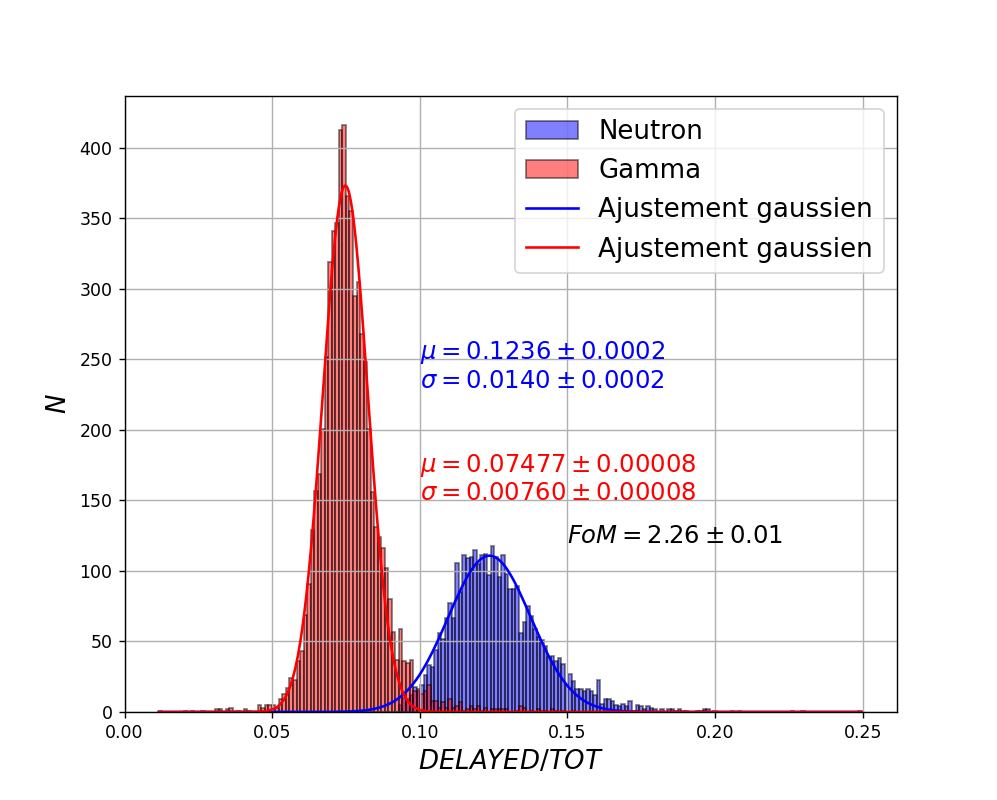

In [370]:
plt.figure()
plt.hist(rE_n_tail_CUT, bins = bins, color = 'blue', edgecolor = 'black', alpha = 0.5, label = 'Neutron')
plt.hist(rE_g_tail_CUT, bins = bins, color = 'red', edgecolor = 'black', alpha = 0.5, label = 'Gamma')
plt.plot(x, gaussian(x, *popt_n_PSD_tail_CUT), '-b', label='Ajustement gaussien')
plt.plot(x, gaussian(x, *popt_g_PSD_tail_CUT), '-r', label='Ajustement gaussien')
#plt.text(0.1, 170, '$\mu = 0.1250 \pm 0.0004$\n$\sigma = 0.0147 \pm 0.0004$', c = 'b', fontsize = 14)
#plt.text(0.1, 120, '$\mu = 0.07614 \pm 0.00009$\n$\sigma = 0.00763 \pm 0.00009$', c = 'r', fontsize = 14)
plt.text(0.1,250,r'$\mu = {:.4f}\pm{:.4f}$'.format(abs(popt_n_PSD_tail_CUT[1]), np.sqrt(pcov_n_PSD_tail_CUT[1, 1])),color='b',fontsize=14)
plt.text(0.1,230,r'$\sigma = {:.4f}\pm{:.4f}$'.format(abs(popt_n_PSD_tail_CUT[2]), np.sqrt(pcov_n_PSD_tail_CUT[2, 2])),color='b',fontsize=14)
plt.text(0.1,170,r'$\mu = {:.5f}\pm{:.5f}$'.format(abs(popt_g_PSD_tail_CUT[1]), np.sqrt(pcov_g_PSD_tail_CUT[1, 1])),color='r',fontsize=14)
plt.text(0.1,150,r'$\sigma = {:.5f}\pm{:.5f}$'.format(abs(popt_g_PSD_tail_CUT[2]), np.sqrt(pcov_g_PSD_tail_CUT[2, 2])),color='r',fontsize=14)
plt.text(0.15, 120,r'$FoM = {:.2f}\pm{:.1}$'.format(FoM_tail_CUT, abs(u_FoM_tail_CUT)),color='k',fontsize=14)

plt.xlabel("$DELAYED/TOT$", fontsize = 15)
plt.ylabel("$N$", fontsize = 15)
plt.legend(loc = 0, fontsize = 15)
plt.xlim(0)
plt.grid()
plt.show() 

<IPython.core.display.Javascript object>


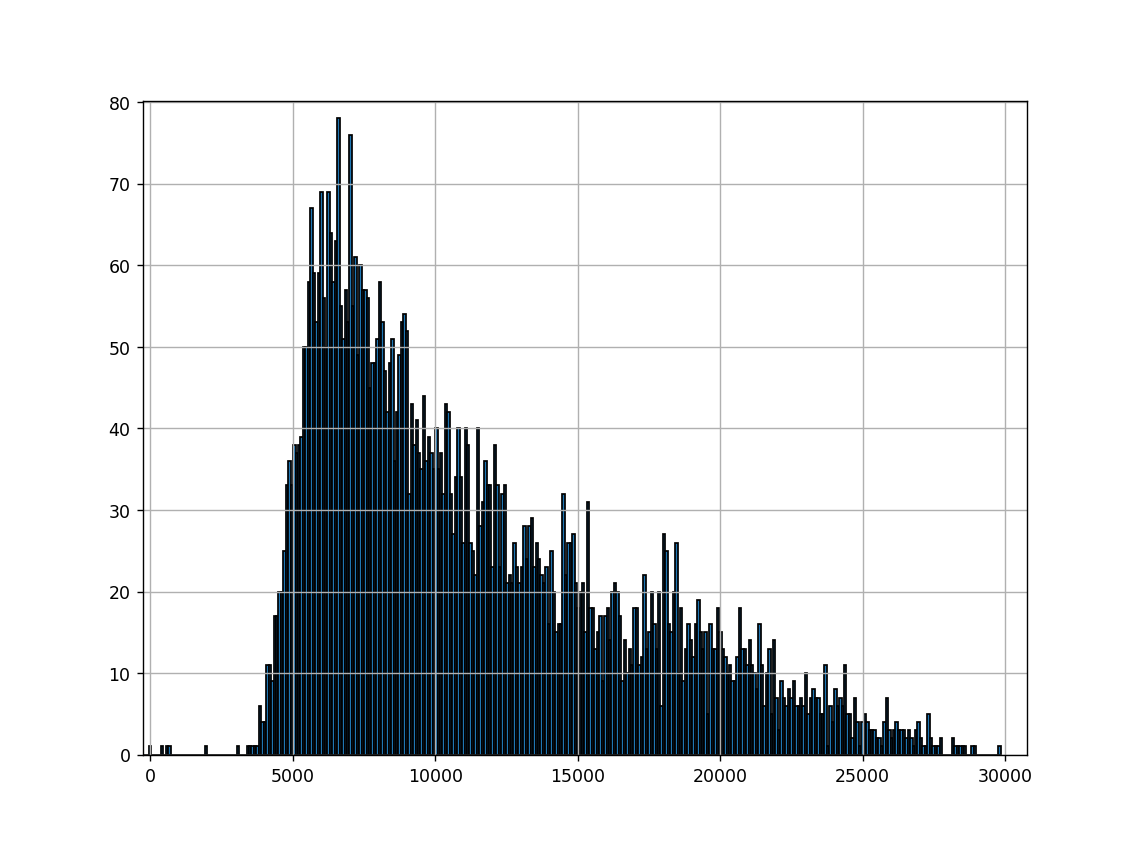

In [401]:
plt.figure()
plt.hist(g_Energy_tot, bins = 400, edgecolor='black')
#plt.semilogy()
plt.grid()
plt.show()

<IPython.core.display.Javascript object>


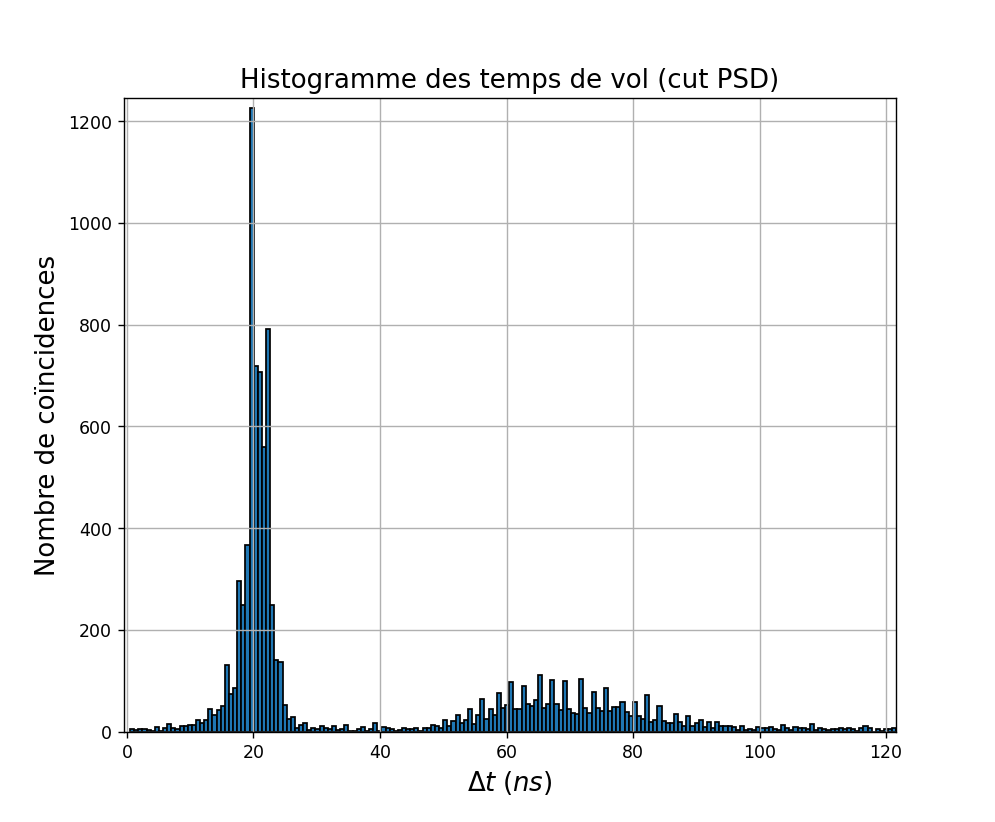

In [263]:
plt.figure()
plt.hist(TOF_CUT, bins = 400, edgecolor='black')

# Ajouter des titres et labels
plt.title("Histogramme des temps de vol (cut PSD)", fontsize = 15)
plt.xlabel("$\Delta t\;(ns)$", fontsize = 15)
plt.ylabel("Nombre de coïncidences", fontsize = 15)

# Afficher l'histogramme
#plt.xlim(0,200)
plt.grid()
#plt.savefig('Histo 110cm 1100V 3000acq')
plt.show() 

<IPython.core.display.Javascript object>


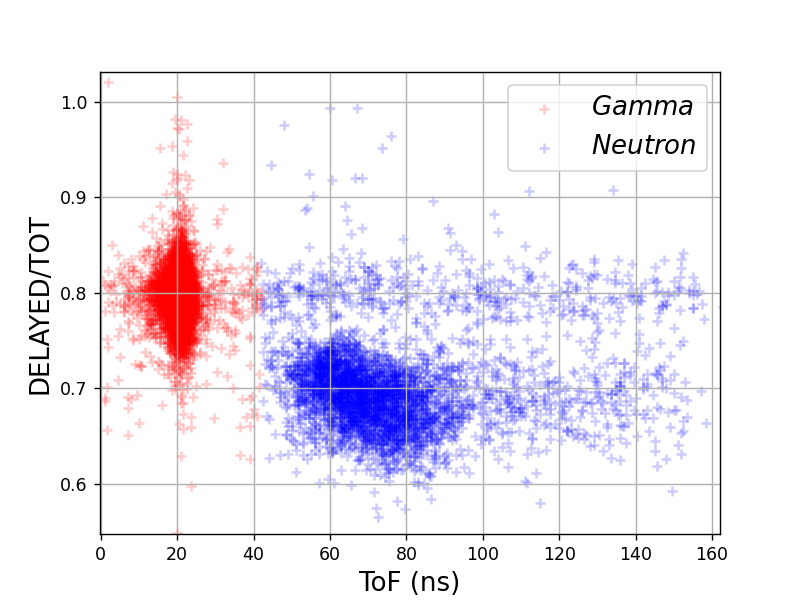

In [32]:
plt.figure()
plt.scatter(TOF_G, g_Energy_fast/g_Energy_tot, marker = '+', c = 'r', alpha = 0.2, label = '$Gamma$')
plt.scatter(TOF_N, n_Energy_fast/n_Energy_tot, marker = '+', c = 'b', alpha = 0.2, label = '$Neutron$')
#plt.plot(X, Y1_1, '--k')
#plt.plot(X, Y1_2, '--k')
plt.xlabel('ToF (ns)', fontsize = 15)
plt.ylabel('FAST/TOT', fontsize = 15)
plt.ylim(0.55, 1)
plt.xlim(0, 160)
plt.legend(loc = 0, fontsize = 15)
plt.grid()
plt.show()

In [238]:
len(TOF_CUT)

42416

In [239]:
test = []

for k in range(len(TOF_CUT)) :
    if TOF_CUT[k] <= 1 :
        test.append(TOF_CUT[k])

In [241]:
len(test)

10746

<IPython.core.display.Javascript object>


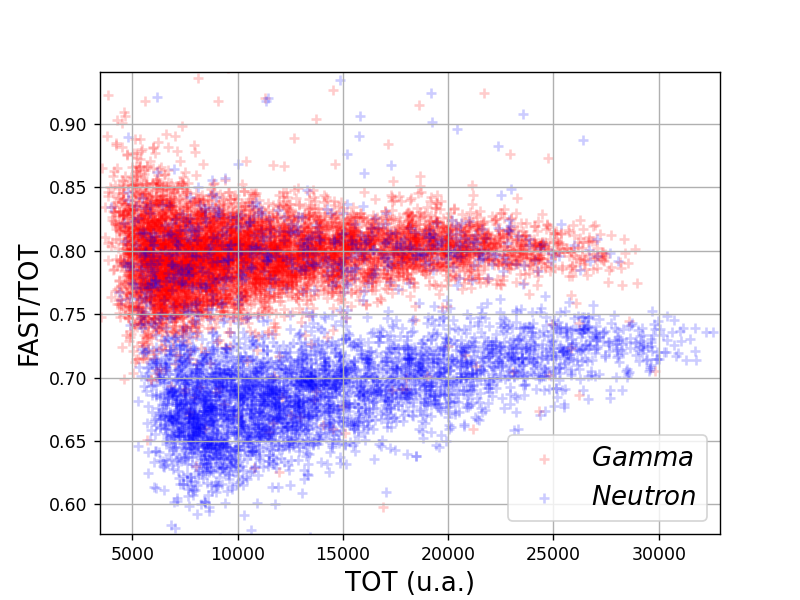

In [34]:
plt.figure()
plt.scatter(g_Energy_tot, g_Energy_fast/g_Energy_tot, marker = '+', c = 'r', alpha = 0.2, label = '$Gamma$')
plt.scatter(n_Energy_tot, n_Energy_fast/n_Energy_tot, marker = '+', c = 'b', alpha = 0.2, label = '$Neutron$')
#plt.plot(X, Y1_1, '--k')
#plt.plot(X, Y1_2, '--k')
plt.xlabel('TOT (u.a.)', fontsize = 15)
plt.ylabel('FAST/TOT', fontsize = 15)
#plt.ylim(0.01, 0.2)
#plt.xlim(3800, 34000)
plt.legend(loc = 0, fontsize = 15)
plt.grid()
plt.show()

<IPython.core.display.Javascript object>


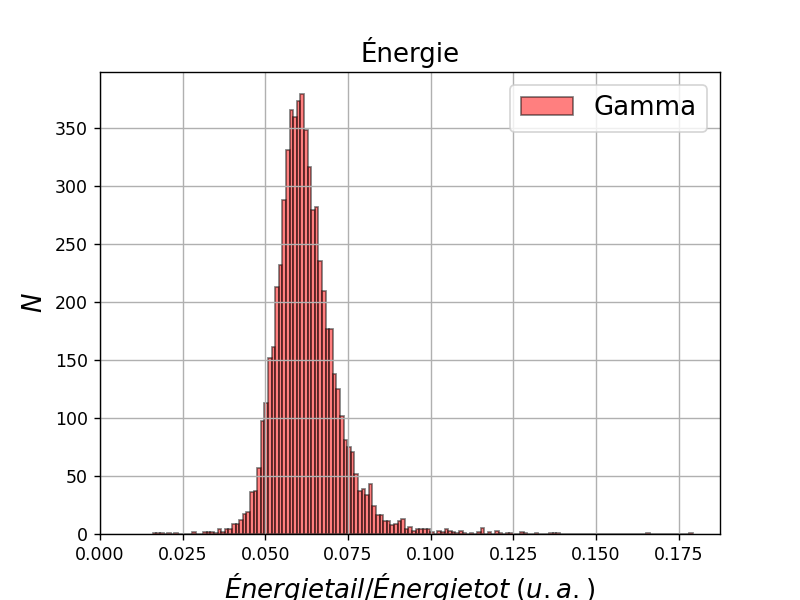

In [39]:
plt.figure()
#plt.hist(n_Energy_tail/n_Energy_tot, bins = 400, edgecolor='blue', alpha = 0.2, label = 'Neutron')
plt.hist(E_g, bins = 150, color = 'red', edgecolor = 'black', alpha = 0.5, label = 'Gamma')
# Ajouter des titres et labels
plt.title("Énergie", fontsize = 15)
plt.xlabel("$Énergie tail/Énergie tot \;(u.a.)$", fontsize = 15)
plt.ylabel("$N$", fontsize = 15)
plt.legend(loc = 0, fontsize = 15)
# Afficher l'histogramme
plt.xlim(0)
plt.grid()
#plt.savefig('Histo 110cm 1100V 3000acq')
plt.show() 

<IPython.core.display.Javascript object>


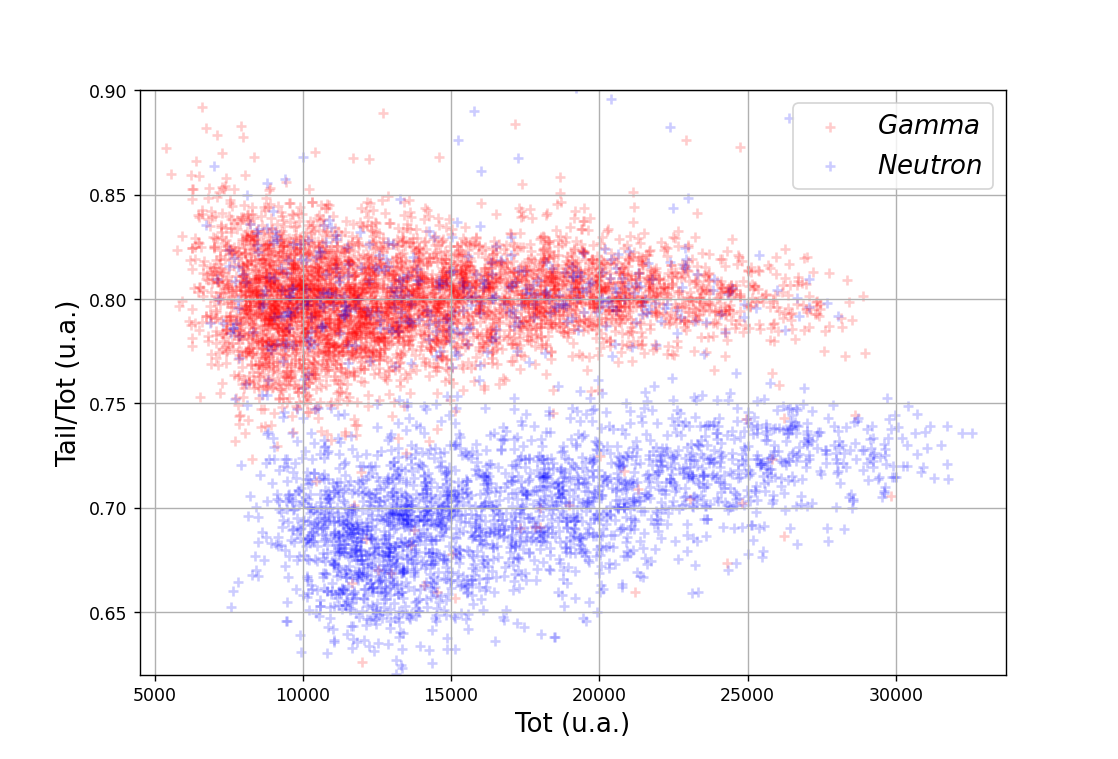

In [501]:
plt.figure()
plt.scatter(g_Energy_tot, g_Energy_fast/g_Energy_tot, marker = '+', c = 'r', alpha = 0.2, label = '$Gamma$')
plt.scatter(n_Energy_tot, n_Energy_fast/n_Energy_tot, marker = '+', c = 'b', alpha = 0.2, label = '$Neutron$')
#plt.plot(X, Y1_1, '--k')
#plt.plot(X, Y1_2, '--k')
plt.xlabel('Tot (u.a.)', fontsize = 15)
plt.ylabel('Tail/Tot', fontsize = 15)
plt.ylim(0.62, 0.9)
plt.xlim(4500, 33700)
plt.legend(loc = 0, fontsize = 15)
plt.grid()
plt.show()

In [ ]:
plt.figure()
plt.hist(n_Energy_fast, bins = 400, edgecolor='blue', alpha = 0.2)
# Ajouter des titres et labels
plt.title("Énergie fast neutrons", fontsize = 15)
plt.xlabel("$Énergie \;(u.a.)", fontsize = 15)
plt.ylabel("$N$", fontsize = 15)

# Afficher l'histogramme
#plt.xlim(0,200)
plt.grid()
#plt.savefig('Histo 110cm 1100V 3000acq')
plt.show() 

In [387]:
np.mean(g_Energy_tail/g_Energy_tot), np.std(g_Energy_tail/g_Energy_tot)

(0.14774618828829394, 0.019747653493319136)

In [388]:
np.mean(n_Energy_tail/n_Energy_tot), np.std(n_Energy_tail/n_Energy_tot) # 100

(0.19664919555704005, 0.02953673759450175)

In [409]:
np.mean(g_Energy_tail/g_Energy_tot), np.std(g_Energy_tail/g_Energy_tot)

(0.14774618828829394, 0.019747653493319136)

In [410]:
np.mean(n_Energy_tail/n_Energy_tot), np.std(n_Energy_tail/n_Energy_tot)  # 1000

(0.19384599607877506, 0.03095780519253352)

In [433]:
np.mean(n_Energy_tail/n_Energy_tot), np.std(n_Energy_tail/n_Energy_tot)

(0.24961526031363143, 0.7586727435571492)

In [445]:
np.mean(n_Energy_tail/n_Energy_tot), np.std(n_Energy_tail/n_Energy_tot)

(0.20263528649107054, 0.036727057151714725)

<IPython.core.display.Javascript object>


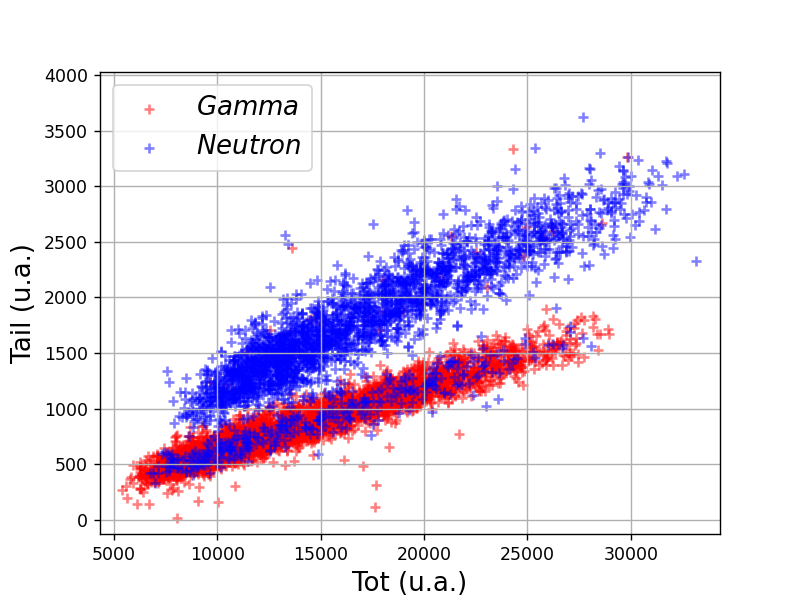

In [570]:
%matplotlib notebook 
plt.figure()
plt.scatter(g_Energy_tot, g_Energy_tail, marker = '+', c = 'r', label = '$Gamma$', alpha = 0.5)
plt.scatter(n_Energy_tot, n_Energy_tail, marker = '+', c = 'b', label = '$Neutron$', alpha = 0.5)
plt.xlabel('Tot (u.a.)', fontsize = 15)
plt.ylabel('Tail (u.a.)', fontsize = 15)
plt.legend(loc = 0, fontsize = 15)
plt.grid()
plt.show()

## Fit signal 

In [264]:
def phos(x, A, B, t1, tau1, tau2):
    return A*np.exp(-(x-t1)/tau1) + B*np.exp(-(x-t1)/tau2)

In [265]:
def fluo(x, A, t1, tau1):
    return A*np.exp(-(x-t1)/tau1) 

In [290]:
n = 110
dt_fluo = 6

In [291]:
popt_fluo, pcov_fluo = curve_fit(fluo, T_NEUTRON[n][np.argmax(NEUTRON[n])+dt_fluo:np.argmax(NEUTRON[n]) +500],
                                 NEUTRON[n][np.argmax(NEUTRON[n])+dt_fluo:np.argmax(NEUTRON[n]) +500],
                                 p0 = [NEUTRON[n][np.argmax(NEUTRON[n])], T_NEUTRON[n][np.argmax(NEUTRON[n])+dt_fluo], 20])

In [292]:
popt_phos, pcov_phos = curve_fit(phos, T_NEUTRON[n][np.argmax(NEUTRON[n])+dt_fluo:np.argmax(NEUTRON[n]) +500],
                                 NEUTRON[n][np.argmax(NEUTRON[n])+dt_fluo:np.argmax(NEUTRON[n]) +500],
                                 p0 = [NEUTRON[n][np.argmax(NEUTRON[n])], NEUTRON[n][np.argmax(NEUTRON[n])],
                                       T_NEUTRON[n][np.argmax(NEUTRON[n])+dt_fluo], 20, 20])

In [293]:
popt_fluo

array([614.78519329, -28.00358683,  14.29927463])

In [294]:
popt_phos

array([ 74.51090205, 593.8392803 , -28.76461329,  70.85743898,
        10.81178133])

In [295]:
t_fluo = np.linspace(T_NEUTRON[n][np.argmax(NEUTRON[n])+dt_fluo], T_NEUTRON[n][np.argmax(NEUTRON[n])+1500], 5000)

<IPython.core.display.Javascript object>


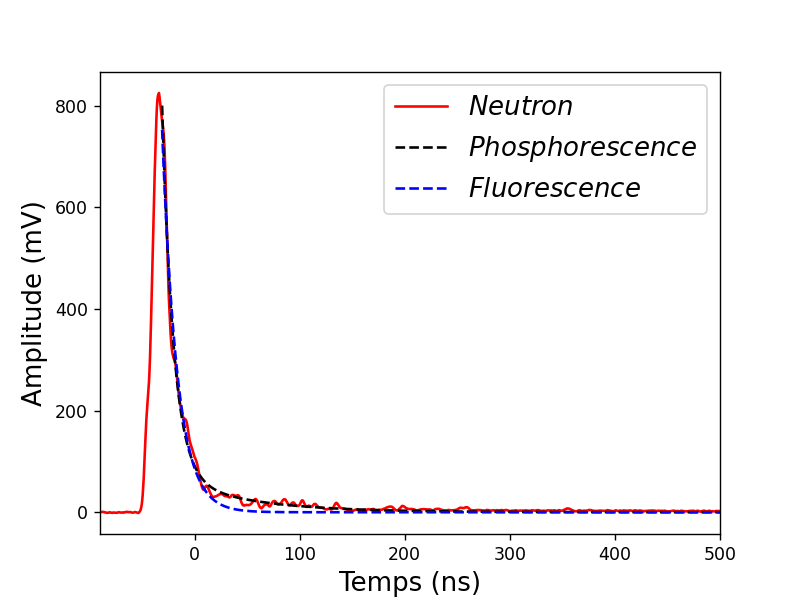

In [296]:
plt.figure()
plt.plot(T_NEUTRON[n], NEUTRON[n], color='r', label = '$Neutron$')
plt.plot(t_fluo, phos(t_fluo, popt_phos[0], popt_phos[1], popt_phos[2], popt_phos[3], popt_phos[4]), '--k', 
         label = '$Phosphorescence$')
plt.plot(t_fluo, fluo(t_fluo, popt_fluo[0], popt_fluo[1], popt_fluo[2]), '--b', label = '$Fluorescence$')
#plt.axvline(T_NEUTRON[n][np.argmax(NEUTRON[n])+dt_fluo], 0, 800)
plt.xlabel('Temps (ns)', fontsize = 15)
plt.ylabel('Amplitude (mV)', fontsize = 15)
plt.legend(loc = 0, fontsize = 15)
plt.xlim(-90, 500)
plt.show()

<IPython.core.display.Javascript object>


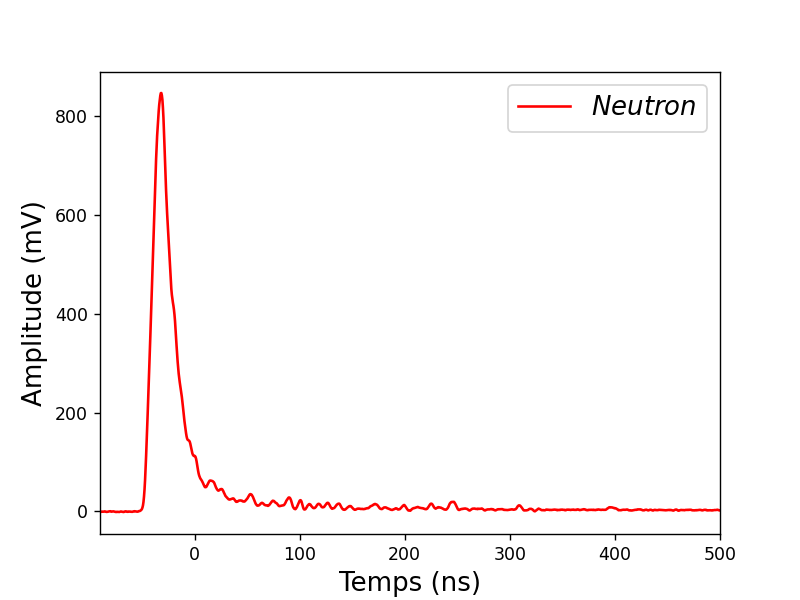

In [204]:
plt.figure()
plt.plot(T_NEUTRON[n], NEUTRON[n], color='r', label = '$Neutron$')
plt.xlabel('Temps (ns)', fontsize = 15)
plt.ylabel('Amplitude (mV)', fontsize = 15)
plt.legend(loc = 0, fontsize = 15)
plt.xlim(-90, 500)
plt.show()

## Énergie des neutrons

In [22]:
### Constantes fondamentales et paramètres du problème

c = 299792458 # m/s
e = 1.602e-19 # C
m_n = 939.565/c**2  # kg

L = 110e-2  # m
U_L = 1e-2  # m

In [23]:
t1_lim = 46  # borne inf : lim neutrons
t2_lim = 116 # brone sup

In [24]:
### Acquisition des ToF qui sont dans l'intervalle [t1_lim, t2_lim]

dt_nl = []  # liste ToF neutrons

for i in range(len(DT_tot)) :
    if DT_tot[i] > t1_lim and DT_tot[i] < t2_lim :
        dt_nl.append(DT_tot[i])
        
dt_n = np.array(dt_nl) - 17 # array ToF neutrons

In [25]:
len(dt_n)

3478

In [26]:
### Comptage occurences temps de vol N_n dans l'intervalle [t1, t2] pas pas de pas_t

N_nl = []
dt_n_newl = []
pas_t = 5  # ns

t1 = t1_lim - 17  # chift de 17 ns : erreur systématique
t2 = t1 + pas_t

while t2 <= t2_lim - 17 :
    N = 0
    dt_n1 = 0

    for i in range(len(dt_n)) :
        if dt_n[i] >= t1 and dt_n[i] < t2 :
            N  += 1
            dt_n1 += dt_n[i]
    
    N_nl.append(N)
    dt_n_newl.append(dt_n1/N)   # moyenne des temps de vol entre t1 et t1 + pas_t
    t1 += pas_t
    t2 += pas_t

N_n = np.array(N_nl)
dt_n_new = np.array(dt_n_newl)

In [27]:
### Calcul des erreurs

U_N_n = np.sqrt(N_n)
U_dt_n_newl = []

t1 = t1_lim - 17
t2 = t1 + pas_t
k = 0
while t2 <= t2_lim - 17 :
    ecart_t = 0

    for i in range(len(dt_n)) :
        if dt_n[i] >= t1 and dt_n[i] < t2 :
            ecart_t += (dt_n[i] - dt_n_new[k])**2
    
    U_dt_n_newl.append(np.sqrt(ecart_t/(N_n[k]-1)))    
    k += 1
    t1 += pas_t
    t2 += pas_t
            
U_dt_n_new = np.array(U_dt_n_newl)         

<IPython.core.display.Javascript object>


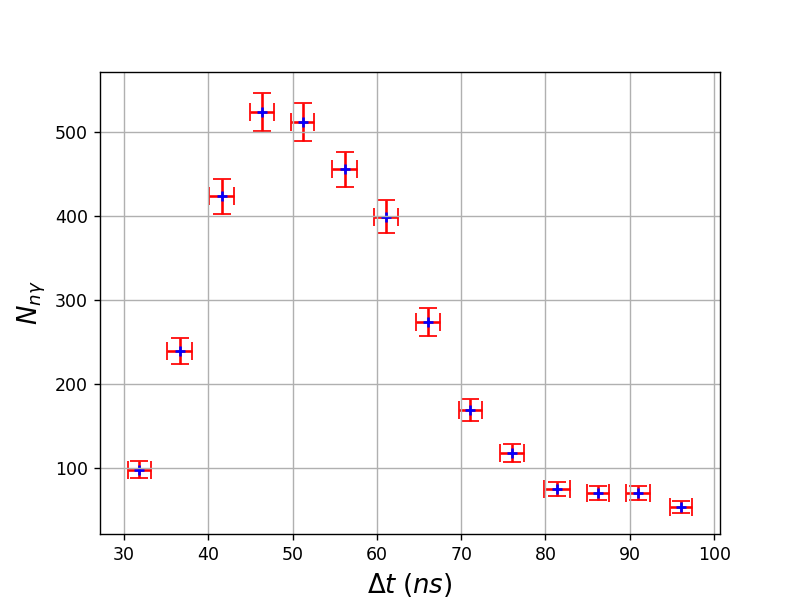

In [62]:
plt.figure()
plt.scatter(dt_n_new, N_n, marker = '+', c = 'b')
plt.errorbar(dt_n_new, N_n, U_N_n, U_dt_n_new, fmt = 'none', capsize = 5, ecolor = 'red', zorder = 0)
plt.xlabel('$\Delta t\;(ns)$', fontsize = 15)
plt.ylabel('$N_{n\gamma}$', fontsize = 15)
plt.grid()
plt.show()

In [28]:
### Calcul de l'énergie des neutrons

v = L/(dt_n_new*1e-9)
U_v = np.array([v[k]*np.sqrt((U_L/L)**2 +(U_dt_n_new[k]/dt_n_new[k])**2) for k in range(len(v))])

E_n = 0.5*m_n*v**2
U_E_n = E_n*U_v/v

In [64]:
Eff = np.array([0.199, 0.214, 0.254, 0.274, 0.3, 0.332, 0.345, 0.364, 0.368, 0.385, 0.387, 0.362, 0.314, 0.21, 0.100, 0.07, 0])

In [65]:
Eff_2 = np.linspace(min(Eff), max(Eff), 1000)

In [66]:
len(Eff)

17

In [67]:
### Dist. Maxwell-Boltzmann

def MB(x, T, N) :
    y = np.exp(-x/T)*N*np.sqrt(x)*T**1.5
    
    return y

In [29]:
### Dist. de Watt

def Watt(x, T, N) :
    y = np.exp(-x/T)*N*np.sinh(np.sqrt(2*x))
    
    return y

In [69]:
### Dist. de Watt

def Watt2(x, T, N) :
    y = np.exp(-x/T)*N*np.sinh(np.sqrt(2*x/T))
    
    return y

In [70]:
E_n_bis, U_E_n_bis = [], []
N_n_bis, U_N_n_bis = [], []
_ = 0
while _ < len(E_n) :
    while _ <= 7 :
        E_n_bis.append(E_n[_])
        N_n_bis.append(N_n[_])
        U_E_n_bis.append(U_E_n[_])
        U_N_n_bis.append(U_N_n[_])
        _ += 1
    
    if _%2 == 0:
        E_n_bis.append(E_n[_])
        N_n_bis.append(N_n[_])
        U_E_n_bis.append(U_E_n[_])
        U_N_n_bis.append(U_N_n[_])
        _ += 1
        
    if _%2 != 0 :
        _ += 1
    
E_n_new = np.array(E_n_bis)
N_n_new = np.array(N_n_bis)
U_E_n_new = np.array(U_E_n_bis)
U_N_n_new = np.array(U_N_n_bis)

In [30]:
I = integrate.simps(N_n/Watt(E_n, 1.17, 0.41), E_n)

<IPython.core.display.Javascript object>


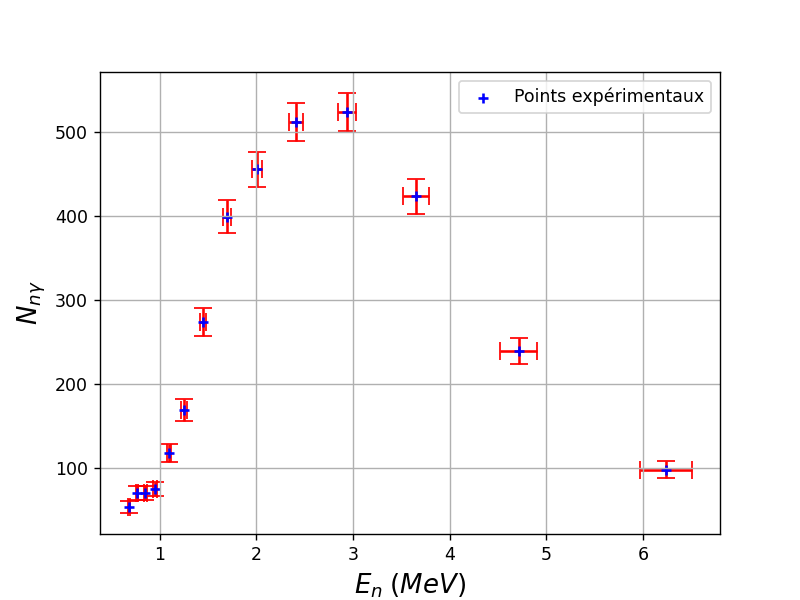

In [72]:
plt.figure()
plt.scatter(E_n, N_n, marker = '+', c = 'b', label = 'Points expérimentaux')
plt.errorbar(E_n, N_n, U_N_n, U_E_n, fmt = 'none', capsize = 5, ecolor = 'red', zorder = 0)
plt.xlabel('$E_n\;(MeV)$', fontsize = 15)
plt.ylabel('$N_{n\gamma}$', fontsize = 15)
plt.legend(loc = 0)
plt.grid()
plt.show()

<IPython.core.display.Javascript object>


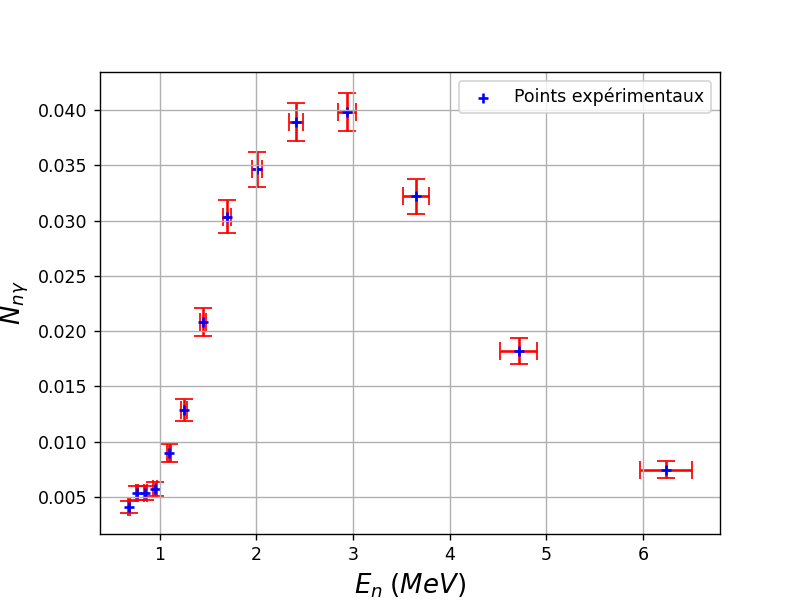

In [73]:
plt.figure()
plt.scatter(E_n, N_n/(abs(I)), marker = '+', c = 'b', label = 'Points expérimentaux')
plt.errorbar(E_n, N_n/(abs(I)), U_N_n/(abs(I)), U_E_n, fmt = 'none', capsize = 5, ecolor = 'red', zorder = 0)
plt.xlabel('$E_n\;(MeV)$', fontsize = 15)
plt.ylabel('$N_{n\gamma}$', fontsize = 15)
plt.legend(loc = 0)
plt.grid()
plt.show()

In [32]:
eff_detec = []
u_eff_detec = []
for k in range(len(E_n)) :
    r = N_n[k]/(abs(I)*Watt(E_n[k], 1.17, 0.41))
    u_eff_detec.append(U_N_n[k]/(abs(I)*Watt(E_n[k], 1.17, 0.41)))
    eff_detec.append(r)

In [33]:
ydec = np.array(eff_detec)/3.75
u_ydec = np.array(u_eff_detec)/3.75

<IPython.core.display.Javascript object>


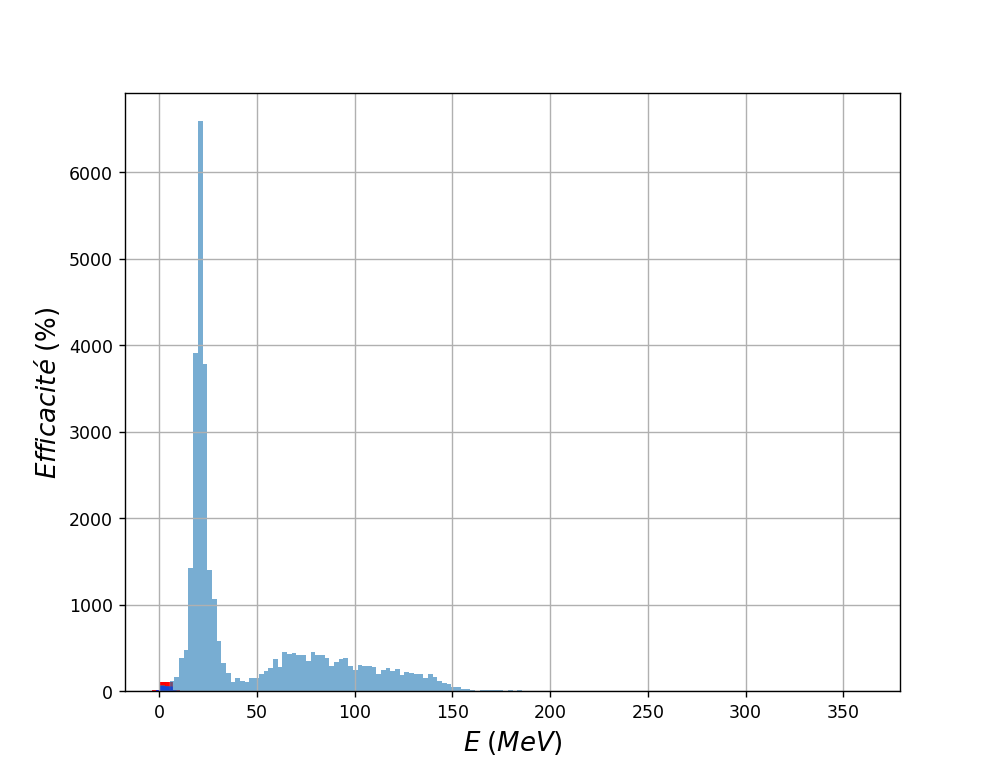

In [188]:
plt.figure()
plt.scatter(E_n, 100*ydec, marker = '+', c = 'b')
plt.errorbar(E_n, 100*ydec, 100*u_ydec, U_E_n, fmt = 'none', capsize = 5, ecolor = 'red', zorder = 0)
plt.xlabel('$E\;(MeV)$', fontsize = 15)
plt.ylabel('$Efficacité \; (\%)$', fontsize = 15)
plt.grid()
plt.show()

In [76]:
qq = integrate.simps(ydec, E_n)/(max(E_n) - min(E_n))

In [77]:
qq

-0.04802749752635803

In [389]:
### Ajustement
popt3, pcov3 = curve_fit(Watt, E_n, N_n/(I*ydec), sigma = np.full_like(N_n/(I*ydec), U_N_n/(I*ydec)), p0 = np.array([1.1, 0.4]))

x = np.linspace(min(E_n), max(E_n), 1000)

In [390]:
popt3[0], popt3[1]

(1.1699999999999997, -0.41000000000000003)

<IPython.core.display.Javascript object>


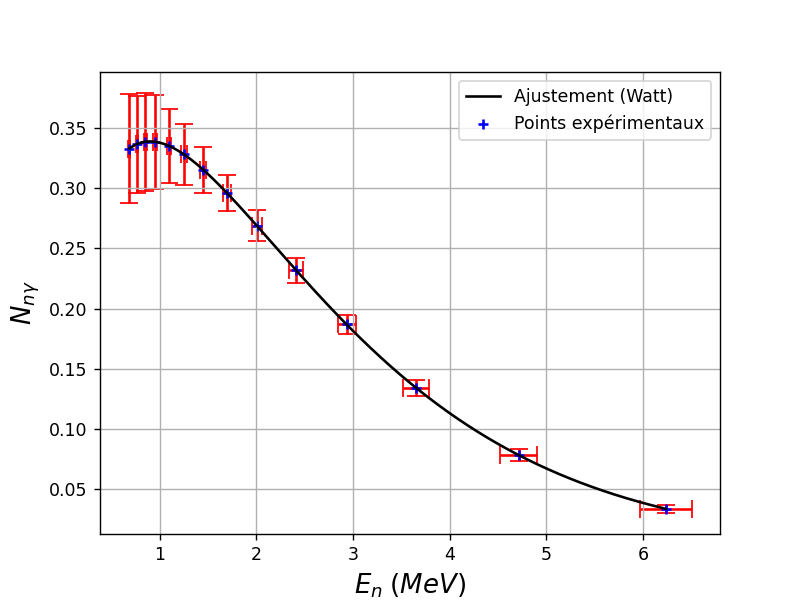

In [393]:
plt.figure()

plt.plot(x, Watt(x, popt3[0], -popt3[1]), '-k', label = 'Ajustement (Watt)')
plt.scatter(E_n, N_n/(abs(I)*ydec), marker = '+', c = 'b', label = 'Points expérimentaux')
plt.errorbar(E_n, N_n/(abs(I)*ydec), U_N_n/(abs(I)*ydec), U_E_n, fmt = 'none', capsize = 5, ecolor = 'red', zorder = 0)
plt.xlabel('$E_n\;(MeV)$', fontsize = 15)
plt.ylabel('$N_{n\gamma}$', fontsize = 15)
plt.legend(loc = 0)
plt.grid()
plt.show()

<IPython.core.display.Javascript object>


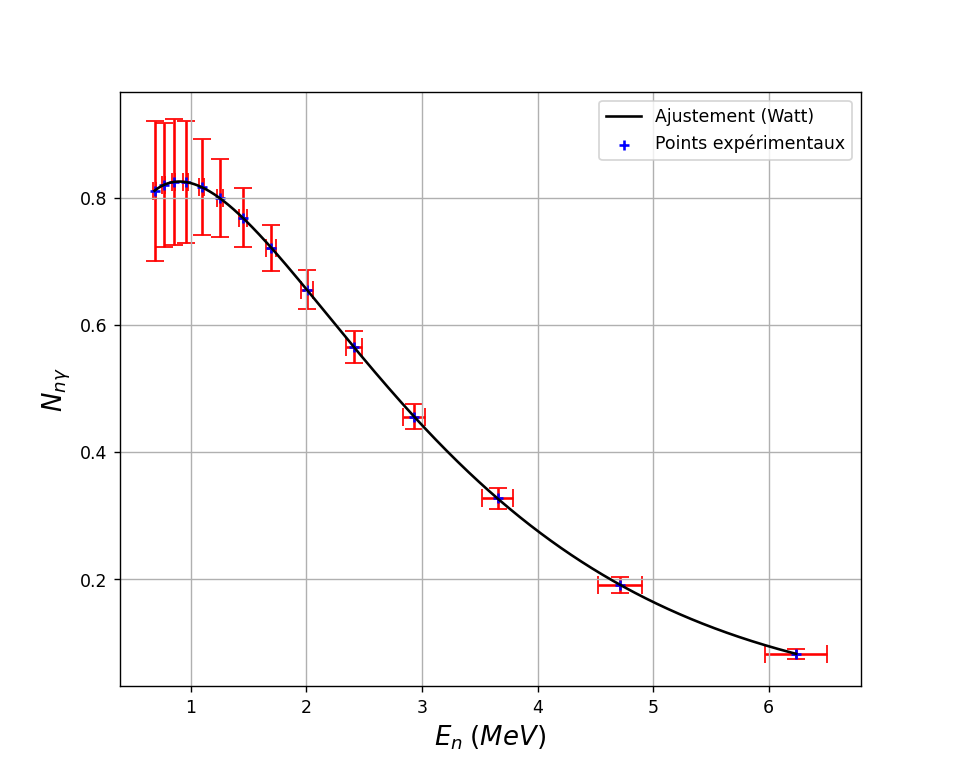

In [373]:
plt.figure()

plt.plot(x, Watt(x, popt3[0], -popt3[1]), '-k', label = 'Ajustement (Watt)')
plt.scatter(E_n, N_n/(abs(I)*ydec), marker = '+', c = 'b', label = 'Points expérimentaux')
plt.errorbar(E_n, N_n/(abs(I)*ydec), U_N_n/(abs(I)*ydec), U_E_n, fmt = 'none', capsize = 5, ecolor = 'red', zorder = 0)
plt.xlabel('$E_n\;(MeV)$', fontsize = 15)
plt.ylabel('$N_{n\gamma}$', fontsize = 15)
plt.legend(loc = 0)
plt.grid()
plt.show()

<IPython.core.display.Javascript object>


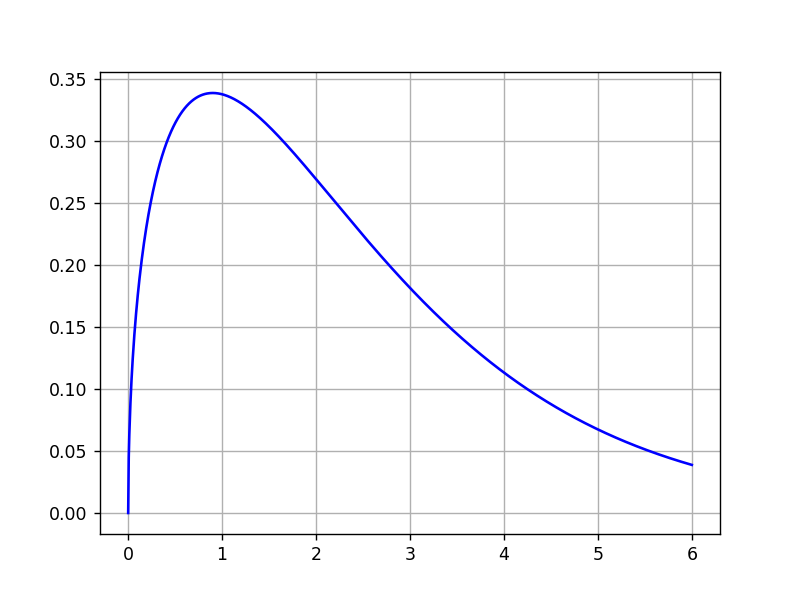

In [374]:
W = np.linspace(0, 6, 1000)

plt.figure()
plt.plot(W, Watt(W, 1.17, 0.41), '-b')
plt.grid()
plt.show()

### Tracer des énergies

In [12]:
DataBa2=np.zeros((2*len(Verif),2560))
DataNE2=np.zeros((2*len(Verif),2560))

for k in range(len(Verif)):
    DataBa2[2*k]=DataBa[2*Verif[k]]
    DataBa2[2*k+1]=DataBa[2*Verif[k]+1]
    DataNE2[2*k]=DataNE[2*Verif[k]]
    DataNE2[2*k+1]=DataNE[2*Verif[k]+1]

DataBa=DataBa2
DataNE=DataNE2
print(len(DataBa))
print(len(DataNE)) 

4658
4658


In [13]:
'''Intégrer'''
from scipy import integrate
EnergyBa=[]
EnergyNE=[]
for k in range(len(Verif)):
    EnergyBa.append(integrate.simps(DataBa[2*k+1], DataBa[2*k]))
    EnergyNE.append(integrate.simps(DataNE[2*k+1], DataNE[2*k]))

print(len(EnergyBa))
print(len(EnergyNE))

2329
2329


<IPython.core.display.Javascript object>


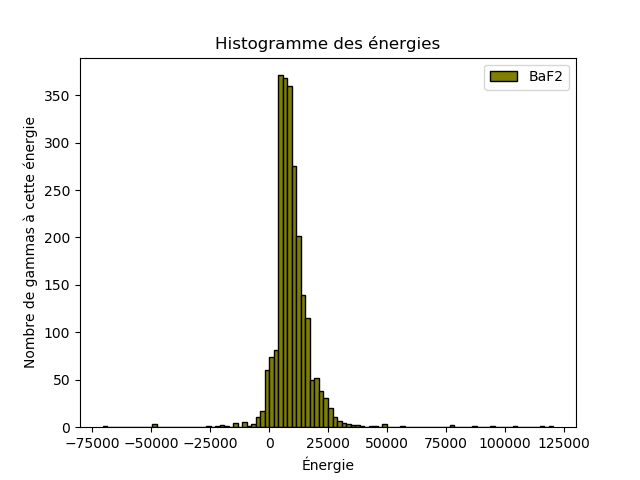

In [15]:
'''Affichage de l histogramme'''
%matplotlib notebook 
# Créer l'histogramme des énergies
#plt.figure(figsize=(10,7))
plt.hist(EnergyBa, bins=100, edgecolor='black', color='olive', label='BaF2')
#plt.hist(EnergyNE, bins=100, edgecolor='black', color='b')

# Ajouter des titres et labels
plt.title("Histogramme des énergies")
plt.xlabel("Énergie") 
plt.ylabel("Nombre de gammas à cette énergie")

# Afficher l'histogramme
#plt.xlim(0,50000)
plt.legend()
plt.show()
